In [1]:
import sys
sys.path.append('..')
import os

import awkward as ak
import numpy as np
import uproot as uproot
import matplotlib.pyplot as plt
import mplhep as hep
import vector as vec
import matplotlib
from tqdm import tqdm

from Timing.plotting import *

from numba import prange

plt.style.use(hep.style.CMS)
%matplotlib inline

In [2]:
def load_branch_with_highest_cycle(file, branch_name):
    # Get all keys in the file
    all_keys = file.keys()
    # Filter keys that match the specified branch name
    matching_keys = [key for key in all_keys if key.startswith(branch_name)]
    if not matching_keys:
        raise ValueError(f"No branch with name '{branch_name}' found in the file.")
    # Find the key with the highest cycle
    highest_cycle_key = max(matching_keys, key=lambda key: int(key.split(";")[1]))
    # Load the branch with the highest cycle
    branch = file[highest_cycle_key]
    return branch

In [3]:
simTsKeys = [
 'regressed_energy',
 'raw_energy',
 # 'raw_em_energy',
 # 'raw_pt',
 # 'raw_em_pt',
 # 'barycenter_x',
 # 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
 # 'EV1',
 # 'EV2',
 # 'EV3',
 # 'eVector0_x',
 # 'eVector0_y',
 # 'eVector0_z',
 # 'sigmaPCA1',
 # 'sigmaPCA2',
 # 'sigmaPCA3',
 # 'regressed_pt',
 # 'pdgID'
]

tsKeys = [
 'regressed_energy',
 'raw_energy',
 # 'raw_em_energy',
 # 'raw_pt',
 # 'raw_em_pt',
 # 'barycenter_x',
 # 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
 # 'EV1',
 # 'EV2',
 # 'EV3',
 # 'eVector0_x',
 # 'eVector0_y',
 # 'eVector0_z',
 # 'sigmaPCA1',
 # 'sigmaPCA2',
 # 'sigmaPCA3'
]

assKeys = ['tsCLUE3D_simToReco_CP',
 'tsCLUE3D_simToReco_CP_score',
 'tsCLUE3D_simToReco_CP_sharedE',
 # 'tsCLUE3D_recoToSim_CP',
 # 'tsCLUE3D_recoToSim_CP_score',
 'tsCLUE3D_recoToSim_CP_sharedE'
          ]

In [4]:
path='/eos/cms/store/group/dpg_hgcal/comm_hgcal/wredjeb/TICLv5Performance/CloseByPionPU/histo/' # CPFromPU
files = os.listdir(path)

### single file

In [5]:
filename = os.path.join(path, files[0])
file = uproot.open(filename)
alltracksters = load_branch_with_highest_cycle(file,'ticlDumper/trackstersCLUE3DHigh')
allsimtrackstersCP = load_branch_with_highest_cycle(file, 'ticlDumper/simtrackstersCP')
allassociations = load_branch_with_highest_cycle(file, 'ticlDumper/associations')
simtrackstersCP = allsimtrackstersCP.arrays(simTsKeys)
tracksters = alltracksters.arrays(tsKeys)
associations = allassociations.arrays(assKeys)

In [19]:
file.keys()

['ticlDumper;1',
 'ticlDumper/trackstersCLUE3DHigh;2',
 'ticlDumper/trackstersCLUE3DHigh;1',
 'ticlDumper/trackstersTiclCandidate;2',
 'ticlDumper/trackstersTiclCandidate;1',
 'ticlDumper/simtrackstersSC;1',
 'ticlDumper/simtrackstersCP;1',
 'ticlDumper/simtracksters2HitsSC;1',
 'ticlDumper/simtracksters2HitsCP;1',
 'ticlDumper/trackstersSuperclusteringDNN;1',
 'ticlDumper/candidates;1',
 'ticlDumper/associations;1',
 'ticlDumper/tracks;1',
 'ticlDumper/simTICLCandidate;1']

(array([4., 5., 6., 7., 6., 6., 7., 5., 3., 1.]),
 array([  8.80403042,  68.37169647, 127.9393692 , 187.5070343 ,
        247.07470703, 306.6423645 , 366.21005249, 425.77770996,
        485.34536743, 544.9130249 , 604.48071289]),
 <BarContainer object of 10 artists>)

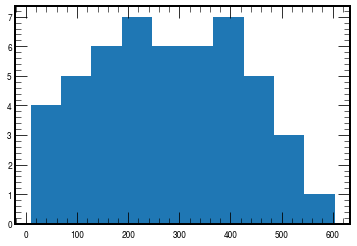

In [6]:
plt.hist(simtrackstersCP.raw_energy)

In [7]:
from numba import njit
import awkward.numba

@njit
def flatten_numba(a):
    return [x[0] if len(x) else 0 for x in a]

def dist(refEta, refPhi, otherTsEta, otherTsPhi):
    return ((otherTsEta-refEta)**2 + (otherTsPhi-refPhi)**2)**0.5

def distWrap(refEta, refPhi, otherTsEta, otherTsPhi):
    # Calculate difference in phi, and wrap it within [-pi, pi]
    deltaPhi = otherTsPhi - refPhi
    deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
    # Euclidean distance considering eta and wrapped phi
    return ((otherTsEta - refEta)**2 + deltaPhi**2)**0.5

@njit
def dist_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        distance = ((otherTsEta[i] - refEta) ** 2 + (otherTsPhi[i] - refPhi) ** 2) ** 0.5
        out.append(distance)
    return np.array(out)

@njit
def distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        deltaPhi = otherTsPhi[i] - refPhi
        deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
        distance = ((otherTsEta[i] - refEta) ** 2 + deltaPhi ** 2) ** 0.5
        out.append(distance)
    return np.array(out)

@njit
def argmaxNumba(arr):
    if len(arr) == 0:
        raise ValueError("argmax: array is empty")
    
    max_index = 0
    max_value = arr[0]

    for i in range(1, len(arr)):
        if arr[i] > max_value:
            max_value = arr[i]
            max_index = i

    return max_index

-0.3927391767501831 [3.08, 0.437, 0.453, 1.14, 0.612, 2.49, ... -0.666, 2.88, -0.62, 2.37, 1.62, -3.06] [5.12745852 4.57904449 4.51856241 ... 3.01971121 2.30543825 2.95200431] [5.51632244 4.57904449 4.51856241 ... 3.01971121 2.30543825 2.95200431]


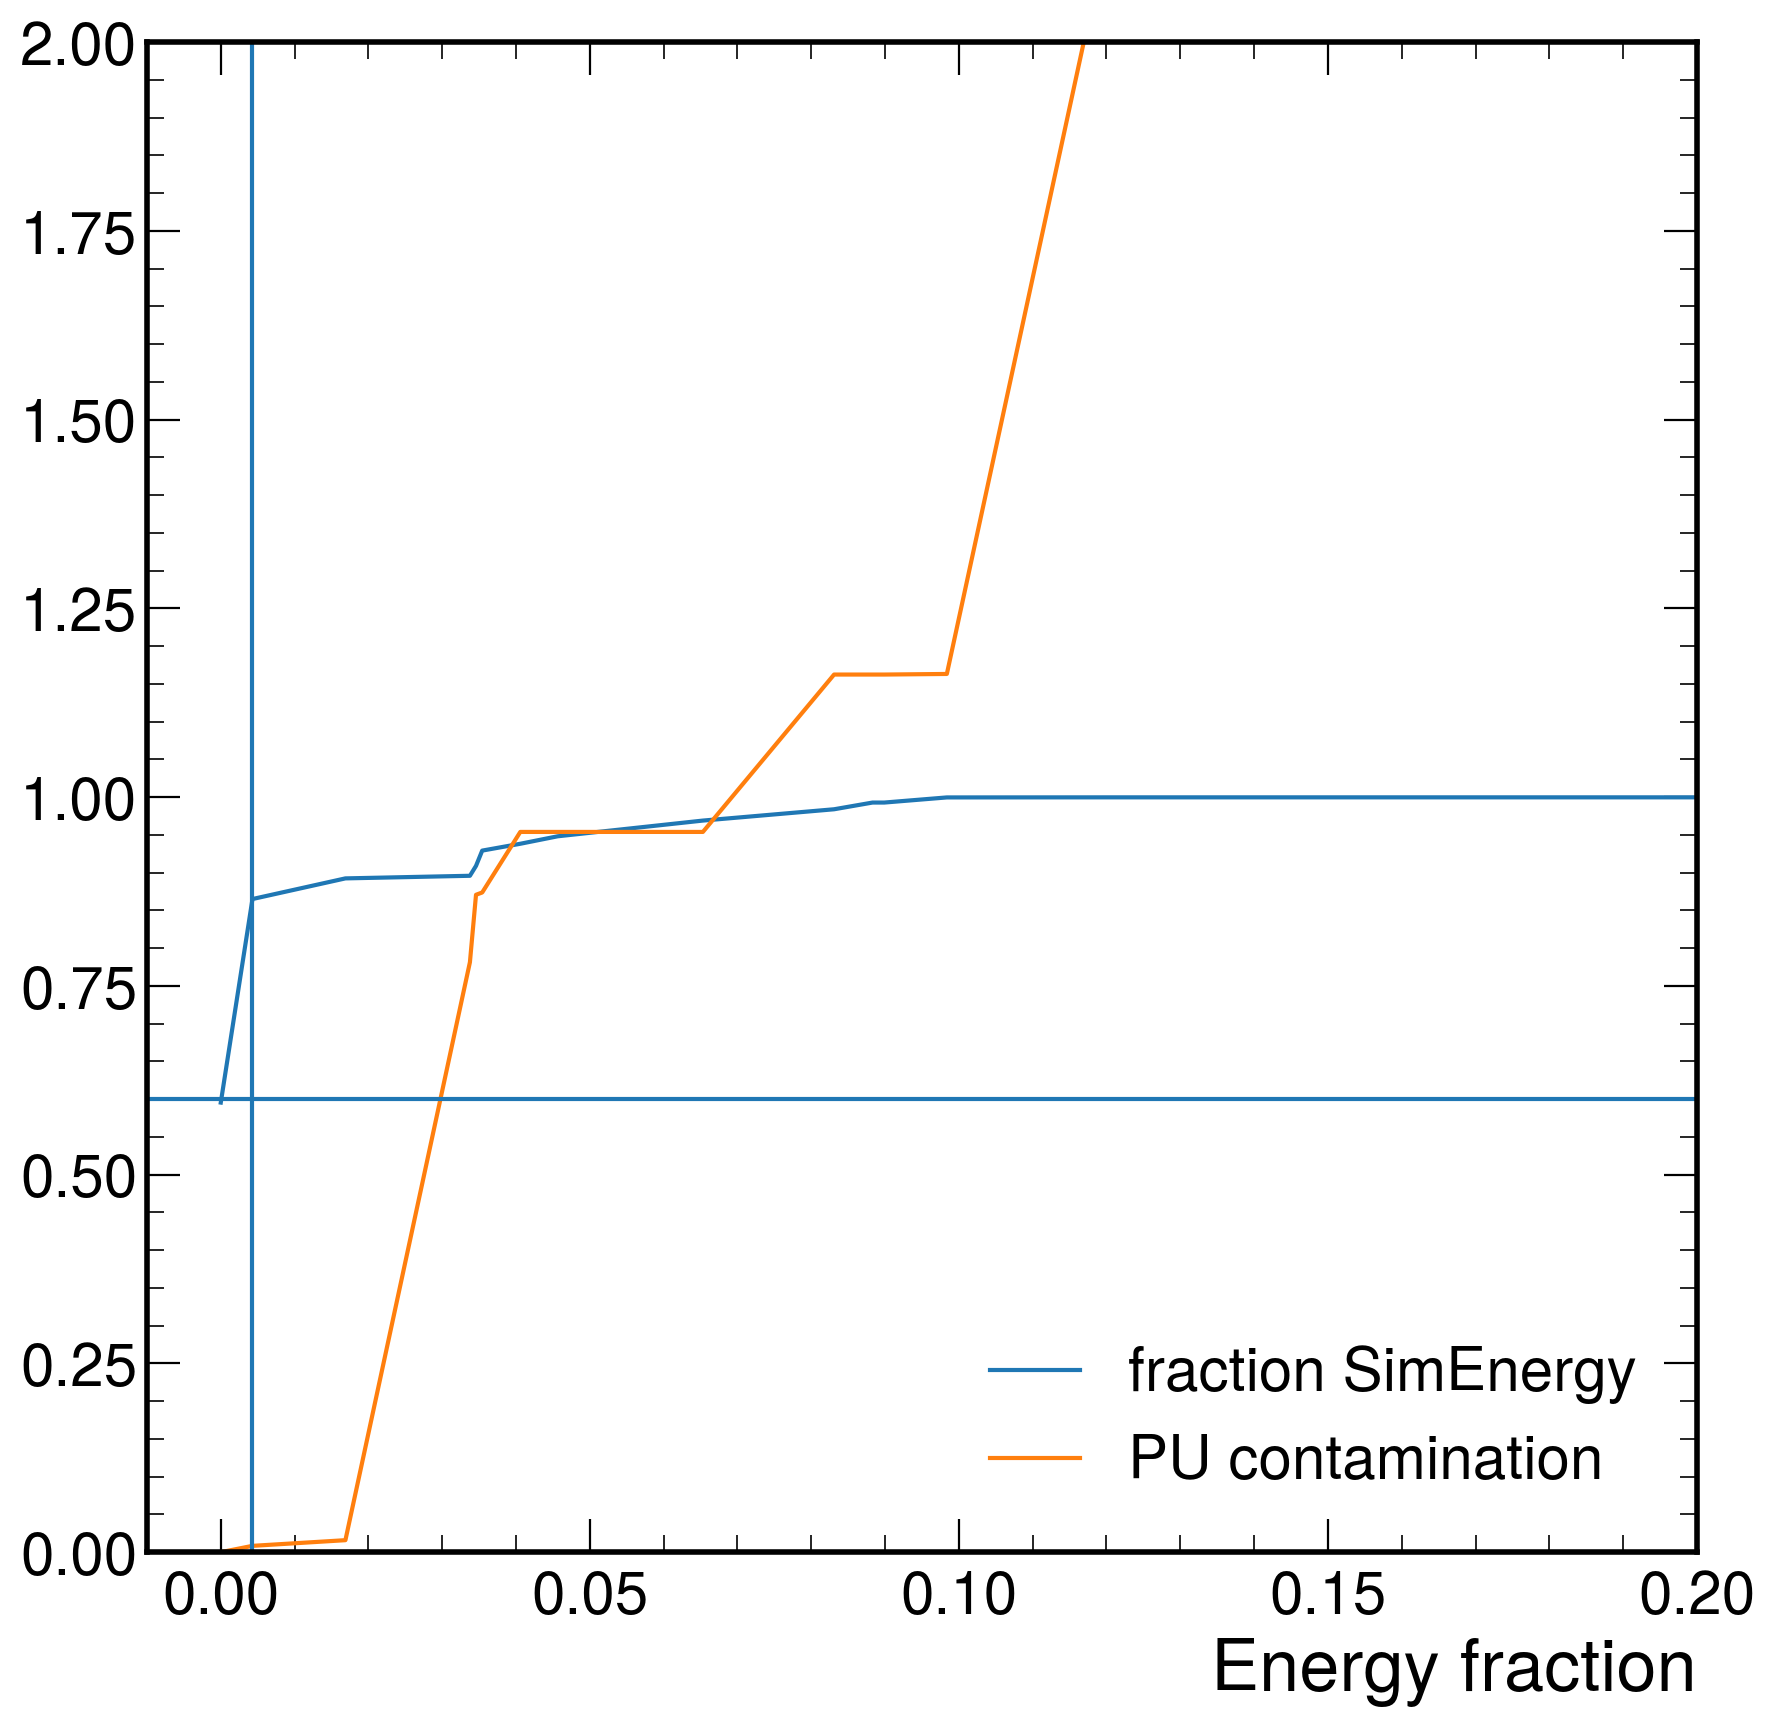

In [8]:
MAX=0.999
CUT=0.6
import time 
ts_info = []
plt.style.use(hep.style.CMS)
plt.figure(dpi=200)
for ev in prange(5): #len(tracksters)):
    start = time.time()
    tsEv = tracksters[ev]
    stsEv = simtrackstersCP[ev]
    assEv = associations[ev]
    if ev!=3:
        continue

    for stId, simEnergy in enumerate(stsEv.raw_energy):
        start = time.time()      
        score = assEv.tsCLUE3D_simToReco_CP_score[stId]
        simToReco = assEv.tsCLUE3D_simToReco_CP[stId] #[score<MAX]
        sharedE = assEv.tsCLUE3D_simToReco_CP_sharedE[stId] #[score<MAX]
        #score = score[score<MAX]

        # trackster with the higher shared energy
        refId = simToReco[np.argmax(sharedE)]
        refZ = tsEv.barycenter_z[refId]
        refEta = tsEv.barycenter_eta[refId]
        refPhi = tsEv.barycenter_phi[refId]
        refEne = tsEv.raw_energy[refId]
        # sort the others by distance in eta-phi
        otherTsEta = tsEv.barycenter_eta
        otherTsPhi = tsEv.barycenter_phi
        distanceWr = distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi)
        distance = dist_numba(refEta, refPhi, otherTsEta, otherTsPhi)
        print(refPhi, otherTsPhi, distanceWr, distance)
        # distance = dist_numba_2(tsEv, refId)
        
        idx_sort = np.array(distance).argsort()
        distance_sorted = distance[idx_sort]
        tsEnergy_sorted = tsEv.raw_energy[idx_sort]
        
        sharedEnergy_sorted = assEv.tsCLUE3D_recoToSim_CP_sharedE[idx_sort]
        # fill empty with zeros and then flatten before cumsum
        sharedEnergy_sorted_flatten = flatten_numba(sharedEnergy_sorted)
        # cumulative fraction of energy around ts
        fractionSimEnergy = np.cumsum(sharedEnergy_sorted_flatten)/np.sum(sharedEnergy_sorted_flatten)
        
        # cumulative pu contamination around ts
        fracRecoEnergy = 1. - sharedEnergy_sorted/tsEnergy_sorted
        fracRecoEnergy_flatten = flatten_numba(fracRecoEnergy)
        fractionRecoEnergy = np.cumsum(fracRecoEnergy_flatten)

        # stop at cut and take r
        firstAboveThrIdx = np.argmax(fractionSimEnergy>CUT)
        if max(fractionSimEnergy) < CUT:
            firstAboveThrIdx = len(fractionSimEnergy)-1
        radius = distance_sorted[firstAboveThrIdx]
        PUcont = fractionRecoEnergy[firstAboveThrIdx]
        
        ts_info.append([ev, refZ, refEta, refPhi, refEne, radius, PUcont])  
        
        plt.plot(distance_sorted, fractionSimEnergy, label='fraction SimEnergy')
        plt.plot(distance_sorted, fractionRecoEnergy, label='PU contamination')
        plt.axhline(CUT)
        plt.axvline(radius)
        plt.legend()
        # plt.xscale("log")
        plt.xlabel("distance in eta-phi")
        plt.xlabel("Energy fraction")
        plt.xlim(-0.01,0.2)
        plt.ylim(0,2)
        # assEv.tsCLUE3D_recoToSim_CP_sharedE[]
    break
plt.show()


## try with two rEM and rHAD

In [9]:
@njit
def findRnumba(fSame, dSame, PUSame, fOther, dOther, PUOther, CUT=0.8):
    rSame = rOther = 0
    PUcont = 99
    totEne = 0
    if not len(dSame):
        # no trackster in same subdet
        firstAboveThrIdx = argmaxNumba(fOther>CUT)
        if max(fOther) < CUT:
            firstAboveThrIdx = len(fOther)-1
        totEne = fOther[firstAboveThrIdx]
        rSame = rOther  = dOther[firstAboveThrIdx]
        PUcont = PUOther[firstAboveThrIdx]   
#         print(f"only other: {rOther=} and {PUcont=}")
    elif not len(dOther):
        # no trackster in other subdet
        firstAboveThrIdx = argmaxNumba(fSame>CUT)
        if max(fSame) < CUT:
            firstAboveThrIdx = len(fSame)-1
        totEne = fOther[firstAboveThrIdx]
        rSame = rOther  = dSame[firstAboveThrIdx]
        PUcont = PUSame[firstAboveThrIdx]  
#         print(f"only same: {rOther=} and {PUcont=}")
    else:
        # tracksters in both
        for eneFrSa, dSa, puSa in zip(fSame, dSame, PUSame):
            for eneFrOth, dOth, puOth in zip(fOther, dOther, PUOther):
                if eneFrSa + eneFrOth < CUT: continue
                if (puSa + puOth) < PUcont:
                    rSame = dSa
                    rOther = dOth
                    PUcont = puSa + puOth
                    totEne = eneFrSa + eneFrOth
    return rSame, rOther, PUcont, totEne

In [10]:
MAX=1
CUT=0.8
import time 
ts_info = []
# plt.style.use(hep.style.CMS)
# fig, axs = plt.subplots(2, 2, figsize=(15,15), dpi=100)
# axs = axs.flatten()

for ev in range(len(tracksters)):
    tsEv = tracksters[ev]
    stsEv = simtrackstersCP[ev]
    assEv = associations[ev]
    print(ev)

    for stId, simEnergy in enumerate(stsEv.raw_energy):
        #score = assEv.tsCLUE3D_simToReco_CP_score[stId]
        simToReco = assEv.tsCLUE3D_simToReco_CP[stId] #[score<MAX]
        sharedE = assEv.tsCLUE3D_simToReco_CP_sharedE[stId] #[score<MAX]
        #score = score[score<MAX]
        if not len(simToReco): continue
        
        # trackster with the higher shared energy
        refId = simToReco[np.argmax(sharedE)]
        refZ = tsEv.barycenter_z[refId]
        refIsHad = abs(tsEv.barycenter_z[refId]) > 368
        refEta = tsEv.barycenter_eta[refId]
        refPhi = tsEv.barycenter_phi[refId]
        refEne = tsEv.raw_energy[refId]
        # sort the others by distance in eta-phi
        otherTsEta = tsEv.barycenter_eta
        otherTsPhi = tsEv.barycenter_phi
        otherTsZ = tsEv.barycenter_z 
        otherTsIsHad = abs(tsEv.barycenter_z) > 368
        distance = distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi)
        
        idx_sort = np.array(distance).argsort()
        distance_sorted = distance[idx_sort]
        tsEnergy_sorted = tsEv.raw_energy[idx_sort]
        otherTsIsHad_sorted = otherTsIsHad[idx_sort]
        ############
        sharedEnergy_sorted = assEv.tsCLUE3D_recoToSim_CP_sharedE[idx_sort]
        # fill empty with zeros and then flatten before cumsum
        all_sharedEnergy_sorted_flatten = flatten_numba(sharedEnergy_sorted)
        c =np.sum(fractionSimEnergy)
        ############
        mask = np.array((np.full(len(otherTsIsHad_sorted), refIsHad) & otherTsIsHad_sorted) | 
                        (np.full(len(otherTsIsHad_sorted), np.logical_not(refIsHad)) & np.logical_not(otherTsIsHad_sorted)))
        
        sharedEnergy_sorted = assEv.tsCLUE3D_recoToSim_CP_sharedE[idx_sort][mask]
        # fill empty with zeros and then flatten before cumsum
        sharedEnergy_sorted_flatten = flatten_numba(sharedEnergy_sorted)
        # cumulative fraction of energy around ts
        fractionSimEnergy = np.cumsum(sharedEnergy_sorted_flatten)/np.sum(all_sharedEnergy_sorted_flatten)
        a=np.sum(fractionSimEnergy)
        
        # cumulative pu contamination around ts
        fracRecoEnergy = 1. - sharedEnergy_sorted/tsEnergy_sorted[mask]
        fracRecoEnergy_flatten = flatten_numba(fracRecoEnergy)
        fractionRecoEnergy = np.cumsum(fracRecoEnergy_flatten)
        
        dSame = distance_sorted[mask]
        fSame = fractionSimEnergy
        PUSame = fractionRecoEnergy

        sharedEnergy_sorted = assEv.tsCLUE3D_recoToSim_CP_sharedE[idx_sort][np.logical_not(mask)]
        # fill empty with zeros and then flatten before cumsum
        sharedEnergy_sorted_flatten = flatten_numba(sharedEnergy_sorted)
        # cumulative fraction of energy around ts
        fractionSimEnergy = np.cumsum(sharedEnergy_sorted_flatten)/np.sum(all_sharedEnergy_sorted_flatten)
        
        # cumulative pu contamination around ts
        fracRecoEnergy = 1. - sharedEnergy_sorted/tsEnergy_sorted[np.logical_not(mask)]
        fracRecoEnergy_flatten = flatten_numba(fracRecoEnergy)
        fractionRecoEnergy = np.cumsum(fracRecoEnergy_flatten)
        
        dOther = distance_sorted[np.logical_not(mask)]
        fOther = fractionSimEnergy
        PUOther = fractionRecoEnergy

        # if the main trackster alone is enough nothing to do
        if fSame[0] > CUT:
            continue

#         dSame = dSame[1:]
#         fSame = fSame[1:]
#         PUSame = PUSame[1:]
            
#         scatterAx(axs[0], dSame[dSame<1], fSame[dSame<1],  color="dodgerblue",  s=30, title=f'fraction as a function of distance', xlabel="R", ylabel=f'fr')
#         scatterAx(axs[1], dSame[dSame<1], PUSame[dSame<1],   s=30, title=f'PU as a function of distance', xlabel="R", ylabel=f'pu')
#         scatterAx(axs[0], dOther[dOther<1], fOther[dOther<1], color="red", s=30, title=f'fraction as a function of distance', xlabel="R", ylabel='fr')
#         scatterAx(axs[1], dOther[dOther<1], PUOther[dOther<1],color="red",  s=30, title=f'PU as a function of distance', xlabel="R", ylabel='pu')
#         print(refIsHad, mask[:5], dSame[:5], dOther[:5])
        
        rSame, rOther, PUcont, totEne = findRnumba(fSame, dSame, PUSame, fOther, dOther, PUOther, CUT)            
#         print(f"both: {rSame=}, {rOther=}, {totEne=} and {PUcont=}")
                                          
        ts_info.append([ev, refZ, refEta, refPhi, refEne, rSame, rOther, PUcont, totEne])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [11]:
zeta = np.array(ts_info).T[1]
eta = np.array(ts_info).T[2]
phi = np.array(ts_info).T[3]
ene = np.array(ts_info).T[4]
rsame = np.array(ts_info).T[5]
rdiff = np.array(ts_info).T[6]
PUc = np.array(ts_info).T[7]
totEne = np.array(ts_info).T[8]

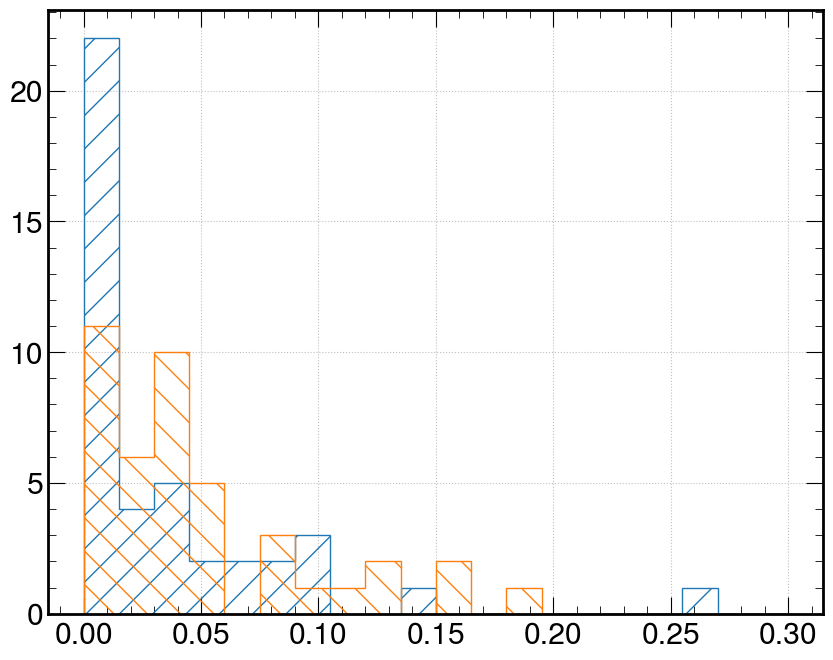

In [12]:
fig = plt.figure(figsize=(10,8), dpi=100)
plt.hist(rsame, range=(0,0.3), bins=20, histtype='step', hatch='/')
plt.hist(rdiff, range=(0,0.3), bins=20, histtype='step', hatch='\\')
plt.grid()
plt.show()

### multiple files

In [13]:
def scatterAx(plt, X, Y, s=10, title='title', xlabel='time (ns)', ylabel='z (cm)', color='dodgerblue'):
    try:
        plt.scatter(ak.flatten(X), ak.flatten(Y), s=ak.flatten(s), color=color)
    except:
        plt.scatter(X, Y, s=s, color=color)
    plt.set_title(title)
    plt.set_xlabel(xlabel)
    plt.set_ylabel(ylabel)
    plt.grid()

In [14]:
CUT=0.8
ts_info = []
ts_dist = []
ts_simShared = []
ts_puCont = []
for f in tqdm(files[:10]):
    filename = os.path.join(path, f)
    file = uproot.open(filename)
    alltracksters = file['ticlDumper/trackstersCLUE3DHigh;1']
    allsimtrackstersCP = file['ticlDumper/simtrackstersCP;1']
    allassociations = file['ticlDumper/associations;1']
    simtrackstersCP = allsimtrackstersCP.arrays(simTsKeys)
    tracksters = alltracksters.arrays(tsKeys)
    associations = allassociations.arrays(assKeys)
#plt.figure(dpi=100)
    for ev in prange(len(tracksters)):
        tsEv = tracksters[ev]
        stsEv = simtrackstersCP[ev]
        assEv = associations[ev]
        
        for stId, simEnergy in enumerate(stsEv.raw_energy):
            #score = assEv.tsCLUE3D_simToReco_CP_score[stId]
            simToReco = assEv.tsCLUE3D_simToReco_CP[stId]
            sharedE = assEv.tsCLUE3D_simToReco_CP_sharedE[stId]
            
            if not len(simToReco):
                continue
            # trackster with the higher shared energy
            refId = simToReco[np.argmax(sharedE)]
            refEta = tsEv.barycenter_eta[refId]
            refZ = tsEv.barycenter_z[refId]
            refPhi = tsEv.barycenter_phi[refId]
            refEne = tsEv.raw_energy[refId]
            # sort the others by distance in eta-phi
            otherTsEta = tsEv.barycenter_eta
            otherTsPhi = tsEv.barycenter_phi
            distance = distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi)
            # distance = dist_numba_2(tsEv, refId)

            idx_sort = np.array(distance).argsort()
            distance_sorted = distance[idx_sort]
            tsEnergy_sorted = tsEv.raw_energy[idx_sort]

            sharedEnergy_sorted = assEv.tsCLUE3D_recoToSim_CP_sharedE[idx_sort]
            # fill empty with zeros and then flatten before cumsum
            sharedEnergy_sorted_flatten = flatten_numba(sharedEnergy_sorted)
            # cumulative fraction of energy around ts
            # fractionSimEnergy = np.cumsum(sharedEnergy_sorted_flatten)/simEnergy
            fractionSimEnergy = np.cumsum(sharedEnergy_sorted_flatten)/np.sum(sharedEnergy_sorted_flatten)

            # cumulative pu contamination around ts
            fracRecoEnergy = 1. - sharedEnergy_sorted/tsEnergy_sorted
            fracRecoEnergy_flatten = flatten_numba(fracRecoEnergy)
            fractionRecoEnergy = np.cumsum(fracRecoEnergy_flatten)

            # stop at cut and take r
            if(fractionSimEnergy[0]>CUT):
                # no link needed
                continue
            firstAboveThrIdx = np.argmax(fractionSimEnergy>CUT)
            radius = distance_sorted[firstAboveThrIdx]
            PUcont = fractionRecoEnergy[firstAboveThrIdx]

            ts_info.append([ev, refZ, refEta, refPhi, refEne, radius, PUcont])  
            ts_dist.append(distance_sorted)  
            ts_simShared.append(fractionSimEnergy)  
            ts_puCont.append(fractionRecoEnergy)

        


100%|██████████| 10/10 [00:35<00:00,  3.56s/it]


In [15]:
zeta = np.array(ts_info).T[1]
eta = np.array(ts_info).T[2]
phi = np.array(ts_info).T[3]
ene = np.array(ts_info).T[4]
radius = np.array(ts_info).T[5]
PUc = np.array(ts_info).T[6]

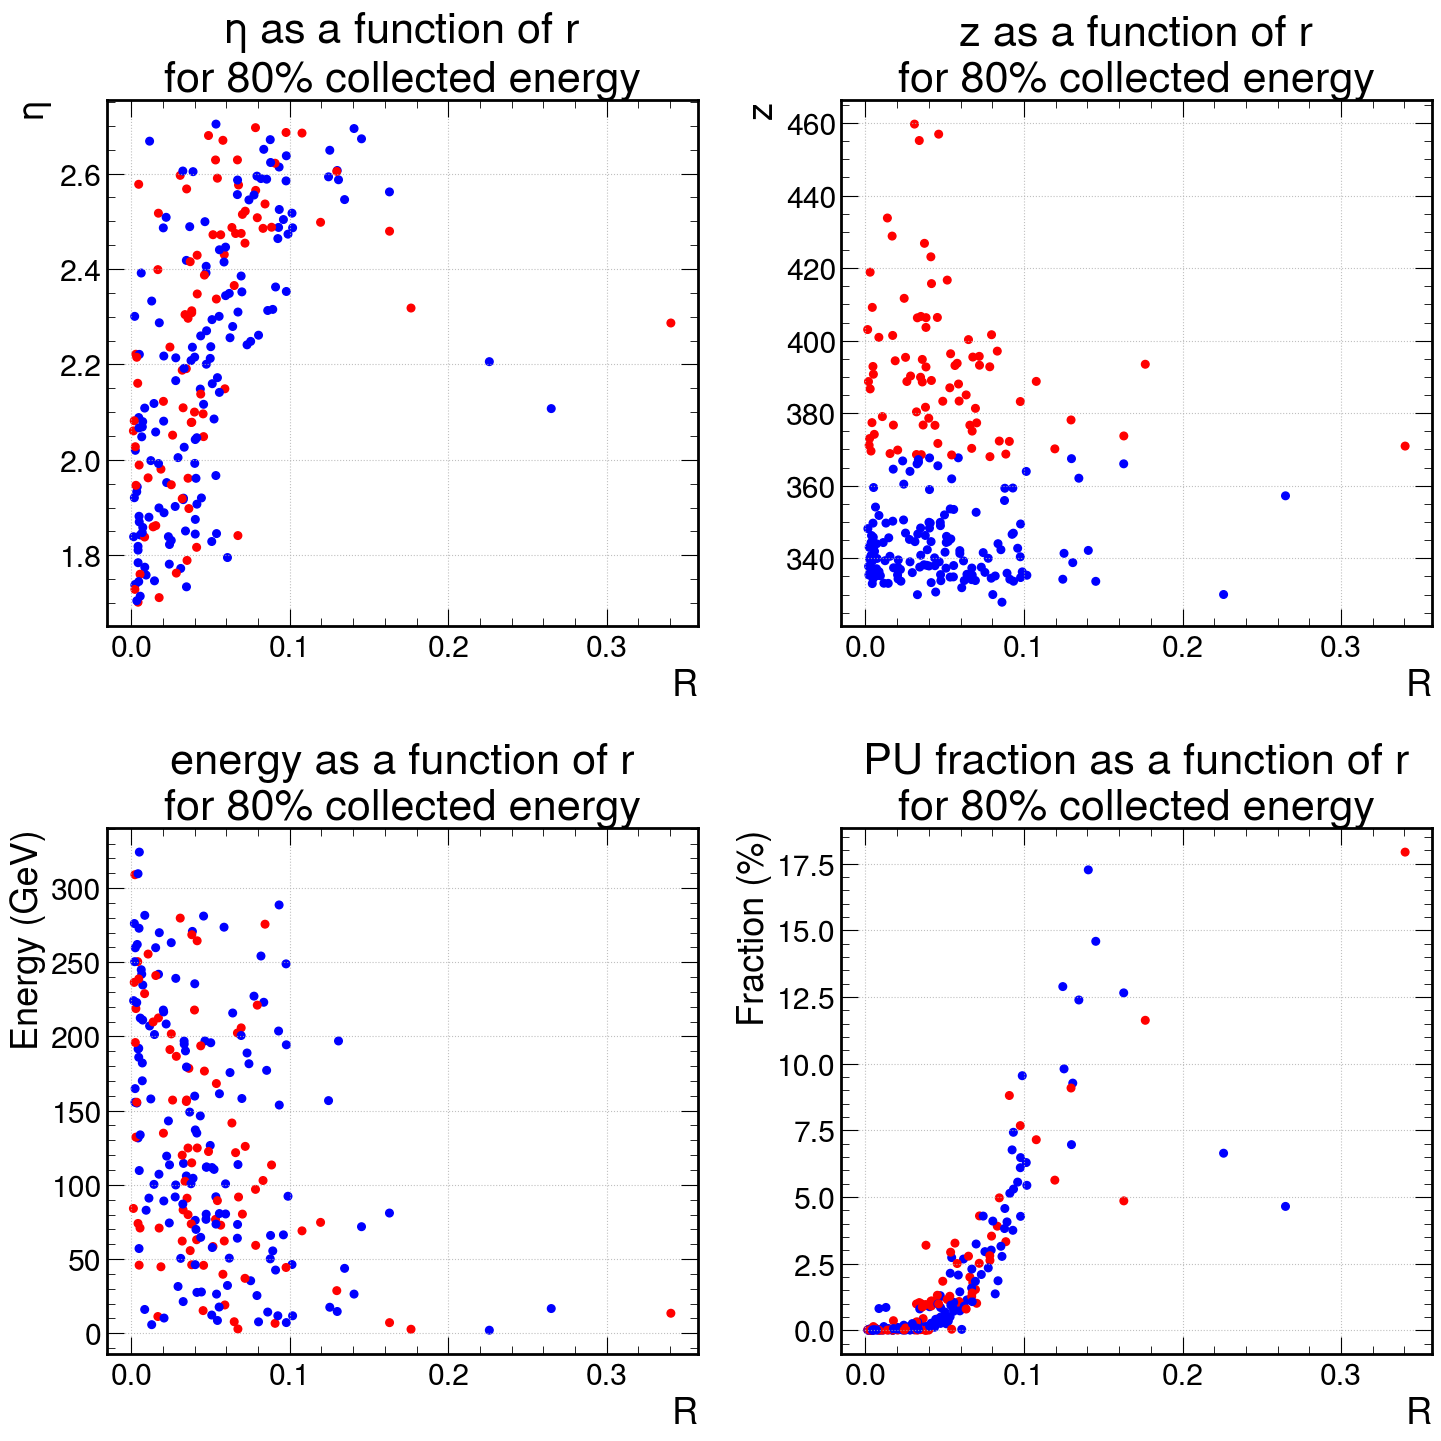

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(15,15), dpi=100)
plt.style.use(hep.style.CMS)

axs = axs.flatten()
c=['red' if abs(z) > 368 else 'blue' for z in zeta]
# Plot each scatter plot on its corresponding axis
scatterAx(axs[0], radius, abs(eta), color=c, s=30, title=f'$\eta$ as a function of r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel=f'$\eta$')
scatterAx(axs[1], radius, zeta,     color=c, s=30, title=f'z as a function of r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel='z')
scatterAx(axs[2], radius, ene,      color=c, s=30, title=f'energy as a function of r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel='Energy (GeV)')
scatterAx(axs[3], radius, PUc,      color=c, s=30, title=f'PU fraction as a function of r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel='Fraction (%)')

plt.tight_layout()  # Automatically adjust subplot parameters to give specified padding
plt.show()

## multiple files with two radii

In [17]:
CUT=0.8
ts_info = []
ts_dist = []
ts_simShared = []
ts_puCont = []
for f in tqdm(files[:10]):
    filename = os.path.join(path, f)
    file = uproot.open(filename)
    alltracksters = file['ticlDumper/trackstersCLUE3DHigh;1']
    allsimtrackstersCP = file['ticlDumper/simtrackstersCP;1']
    allassociations = file['ticlDumper/associations;1']
    simtrackstersCP = allsimtrackstersCP.arrays(simTsKeys)
    tracksters = alltracksters.arrays(tsKeys)
    associations = allassociations.arrays(assKeys)

    for ev in range(len(tracksters)):
        tsEv = tracksters[ev]
        stsEv = simtrackstersCP[ev]
        assEv = associations[ev]

        for stId, simEnergy in enumerate(stsEv.raw_energy):
            #score = assEv.tsCLUE3D_simToReco_CP_score[stId]
            simToReco = assEv.tsCLUE3D_simToReco_CP[stId] #[score<MAX]
            sharedE = assEv.tsCLUE3D_simToReco_CP_sharedE[stId] #[score<MAX]
            #score = score[score<MAX]
            if not len(simToReco): continue

            # trackster with the higher shared energy
            refId = simToReco[np.argmax(sharedE)]
            refZ = tsEv.barycenter_z[refId]
            refIsHad = abs(tsEv.barycenter_z[refId]) > 368
            refEta = tsEv.barycenter_eta[refId]
            refPhi = tsEv.barycenter_phi[refId]
            refEne = tsEv.raw_energy[refId]
            # sort the others by distance in eta-phi
            otherTsEta = tsEv.barycenter_eta
            otherTsPhi = tsEv.barycenter_phi
            otherTsZ = tsEv.barycenter_z 
            otherTsIsHad = abs(tsEv.barycenter_z) > 368
            distance = distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi)

            idx_sort = np.array(distance).argsort()
            distance_sorted = distance[idx_sort]
            tsEnergy_sorted = tsEv.raw_energy[idx_sort]
            otherTsIsHad_sorted = otherTsIsHad[idx_sort]
            ############
            sharedEnergy_sorted = assEv.tsCLUE3D_recoToSim_CP_sharedE[idx_sort]
            # fill empty with zeros and then flatten before cumsum
            all_sharedEnergy_sorted_flatten = flatten_numba(sharedEnergy_sorted)
            c =np.sum(fractionSimEnergy)
            ############
            mask = np.array((np.full(len(otherTsIsHad_sorted), refIsHad) & otherTsIsHad_sorted) | 
                            (np.full(len(otherTsIsHad_sorted), np.logical_not(refIsHad)) & np.logical_not(otherTsIsHad_sorted)))

            sharedEnergy_sorted = assEv.tsCLUE3D_recoToSim_CP_sharedE[idx_sort][mask]
            # fill empty with zeros and then flatten before cumsum
            sharedEnergy_sorted_flatten = flatten_numba(sharedEnergy_sorted)
            # cumulative fraction of energy around ts
            fractionSimEnergy = np.cumsum(sharedEnergy_sorted_flatten)/np.sum(all_sharedEnergy_sorted_flatten)
            a=np.sum(fractionSimEnergy)

            # cumulative pu contamination around ts
            fracRecoEnergy = 1. - sharedEnergy_sorted/tsEnergy_sorted[mask]
            fracRecoEnergy_flatten = flatten_numba(fracRecoEnergy)
            fractionRecoEnergy = np.cumsum(fracRecoEnergy_flatten)

            dSame = distance_sorted[mask]
            fSame = fractionSimEnergy
            PUSame = fractionRecoEnergy

            sharedEnergy_sorted = assEv.tsCLUE3D_recoToSim_CP_sharedE[idx_sort][np.logical_not(mask)]
            # fill empty with zeros and then flatten before cumsum
            sharedEnergy_sorted_flatten = flatten_numba(sharedEnergy_sorted)
            # cumulative fraction of energy around ts
            fractionSimEnergy = np.cumsum(sharedEnergy_sorted_flatten)/np.sum(all_sharedEnergy_sorted_flatten)

            # cumulative pu contamination around ts
            fracRecoEnergy = 1. - sharedEnergy_sorted/tsEnergy_sorted[np.logical_not(mask)]
            fracRecoEnergy_flatten = flatten_numba(fracRecoEnergy)
            fractionRecoEnergy = np.cumsum(fracRecoEnergy_flatten)

            dOther = distance_sorted[np.logical_not(mask)]
            fOther = fractionSimEnergy
            PUOther = fractionRecoEnergy

            # if the main trackster alone is enough nothing to do
            if fSame[0] > CUT:
                continue
            
            rSame, rOther, PUcont, totEne = findRnumba(fSame, dSame, PUSame, fOther, dOther, PUOther, CUT)            


            ts_info.append([ev, refZ, refEta, refPhi, refEne, rSame, rOther, PUcont])

#             ts_info.append([ev, refZ, refEta, refPhi, refEne, radius, PUcont])  
            ts_dist.append(distance_sorted)  
            ts_simShared.append(fractionSimEnergy)  
            ts_puCont.append(fractionRecoEnergy)

        


100%|██████████| 10/10 [00:30<00:00,  3.09s/it]


In [18]:
zeta = np.array(ts_info).T[1]
eta = np.array(ts_info).T[2]
phi = np.array(ts_info).T[3]
ene = np.array(ts_info).T[4]
rsame = np.array(ts_info).T[5]
rdiff = np.array(ts_info).T[6]
PUc = np.array(ts_info).T[7]

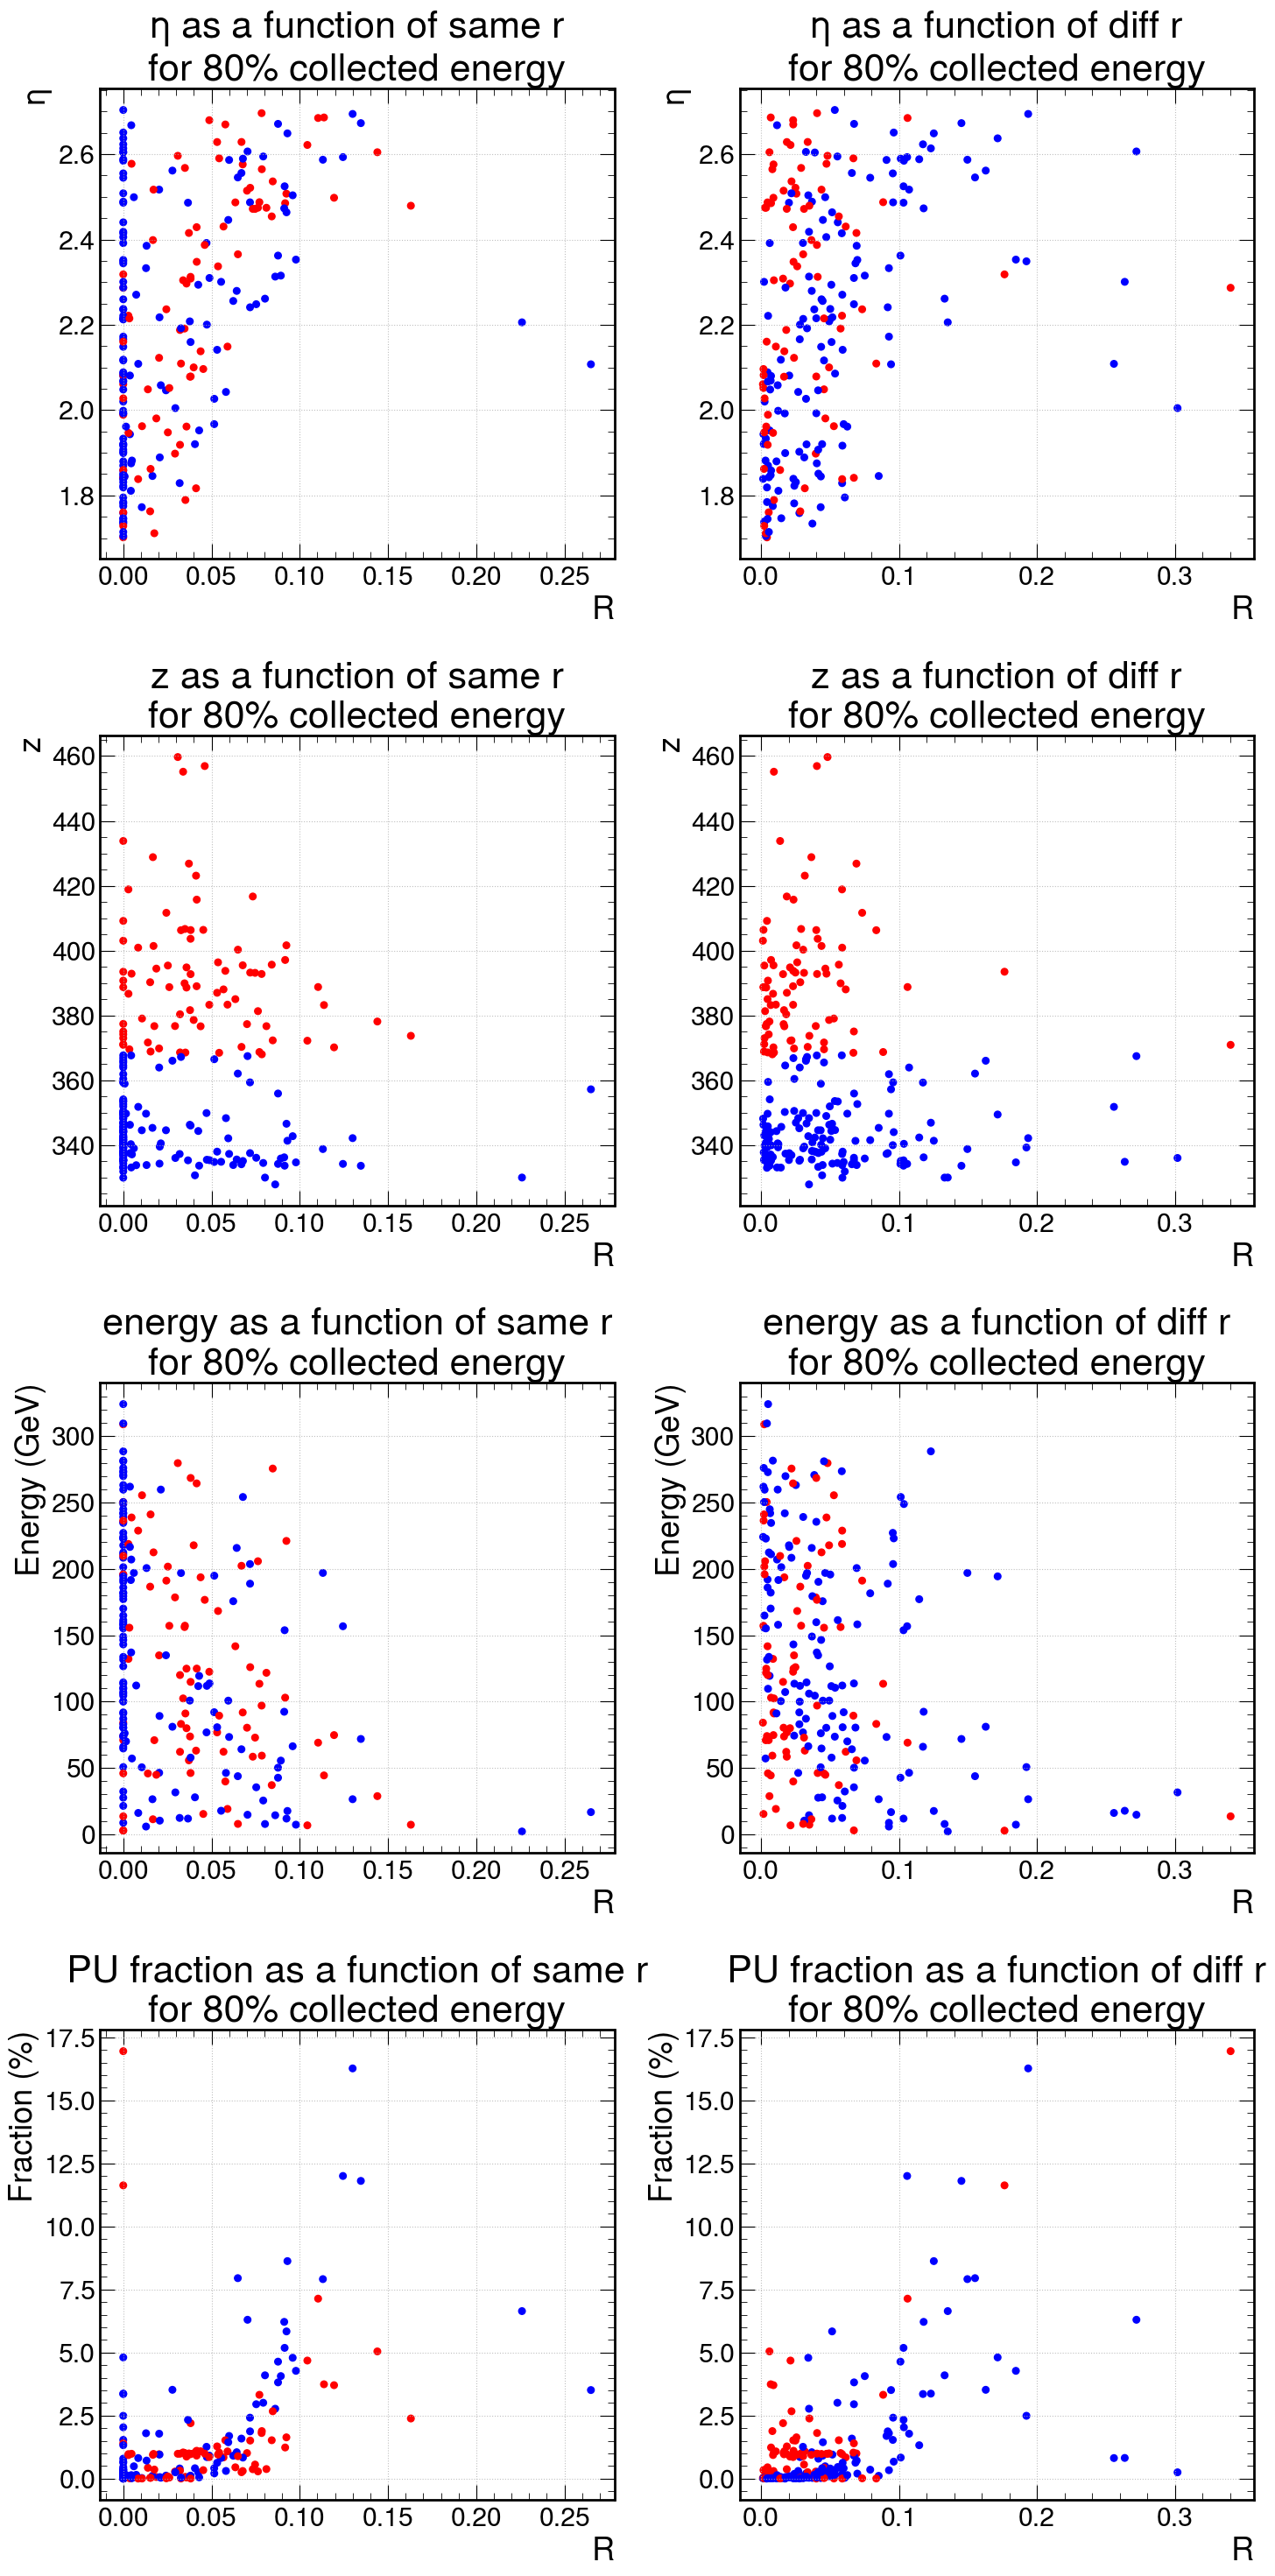

In [19]:
fig, axs = plt.subplots(4, 2, figsize=(15,30), dpi=100)
plt.style.use(hep.style.CMS)

axs = axs.flatten()
c=['red' if abs(z) > 368 else 'blue' for z in zeta]
# Plot each scatter plot on its corresponding axis
scatterAx(axs[0], rsame, abs(eta), color=c, s=30, title=f'$\eta$ as a function of same r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel=f'$\eta$')
scatterAx(axs[1], rdiff, abs(eta), color=c, s=30, title=f'$\eta$ as a function of diff r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel=f'$\eta$')
scatterAx(axs[2], rsame, zeta,     color=c, s=30, title=f'z as a function of same r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel='z')
scatterAx(axs[3], rdiff, zeta,     color=c, s=30, title=f'z as a function of diff r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel='z')
scatterAx(axs[4], rsame, ene,      color=c, s=30, title=f'energy as a function of same r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel='Energy (GeV)')
scatterAx(axs[5], rdiff, ene,      color=c, s=30, title=f'energy as a function of diff r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel='Energy (GeV)')
scatterAx(axs[6], rsame, PUc,      color=c, s=30, title=f'PU fraction as a function of same r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel='Fraction (%)')
scatterAx(axs[7], rdiff, PUc,      color=c, s=30, title=f'PU fraction as a function of diff r\nfor {CUT*100:.0f}% collected energy', xlabel="R", ylabel='Fraction (%)')

plt.tight_layout()  # Automatically adjust subplot parameters to give specified padding
plt.show()

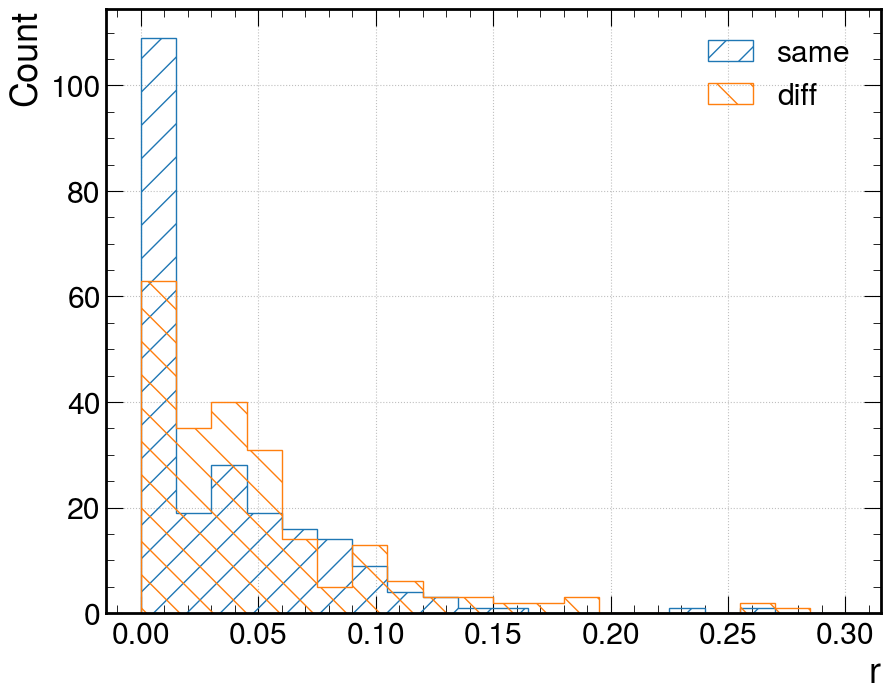

In [20]:
fig = plt.figure(figsize=(10,8), dpi=100)
plt.hist(rsame, range=(0,0.3), bins=20, histtype='step', hatch='/', label="same")
plt.hist(rdiff, range=(0,0.3), bins=20, histtype='step', hatch='\\', label="diff")
plt.grid()
plt.xlabel("r")
plt.ylabel("Count")
plt.legend()
plt.show()

In [21]:
# def print_avg(eta, label="variable"):
#     avg_eta = np.mean(eta)
#     se_eta = np.std(eta)
#     print(f"Average of {label}: {avg_eta:.5f}, Error: {se_eta:.5f}")
    
# # Calculate the averages
# print_avg(eta, "Eta")
# print_avg(phi, "Phi")
# print_avg(ene, "Energy")
# print_avg(PUc, "PU")
# print_avg(rad, "radius")

## ROC

In [22]:
dist = np.linspace(0,0.1,50)

In [23]:
ID=0
distance = ts_dist[ID]
fractionSimEnergy = ts_simShared[ID]
fractionRecoEnergy = ts_puCont[ID]

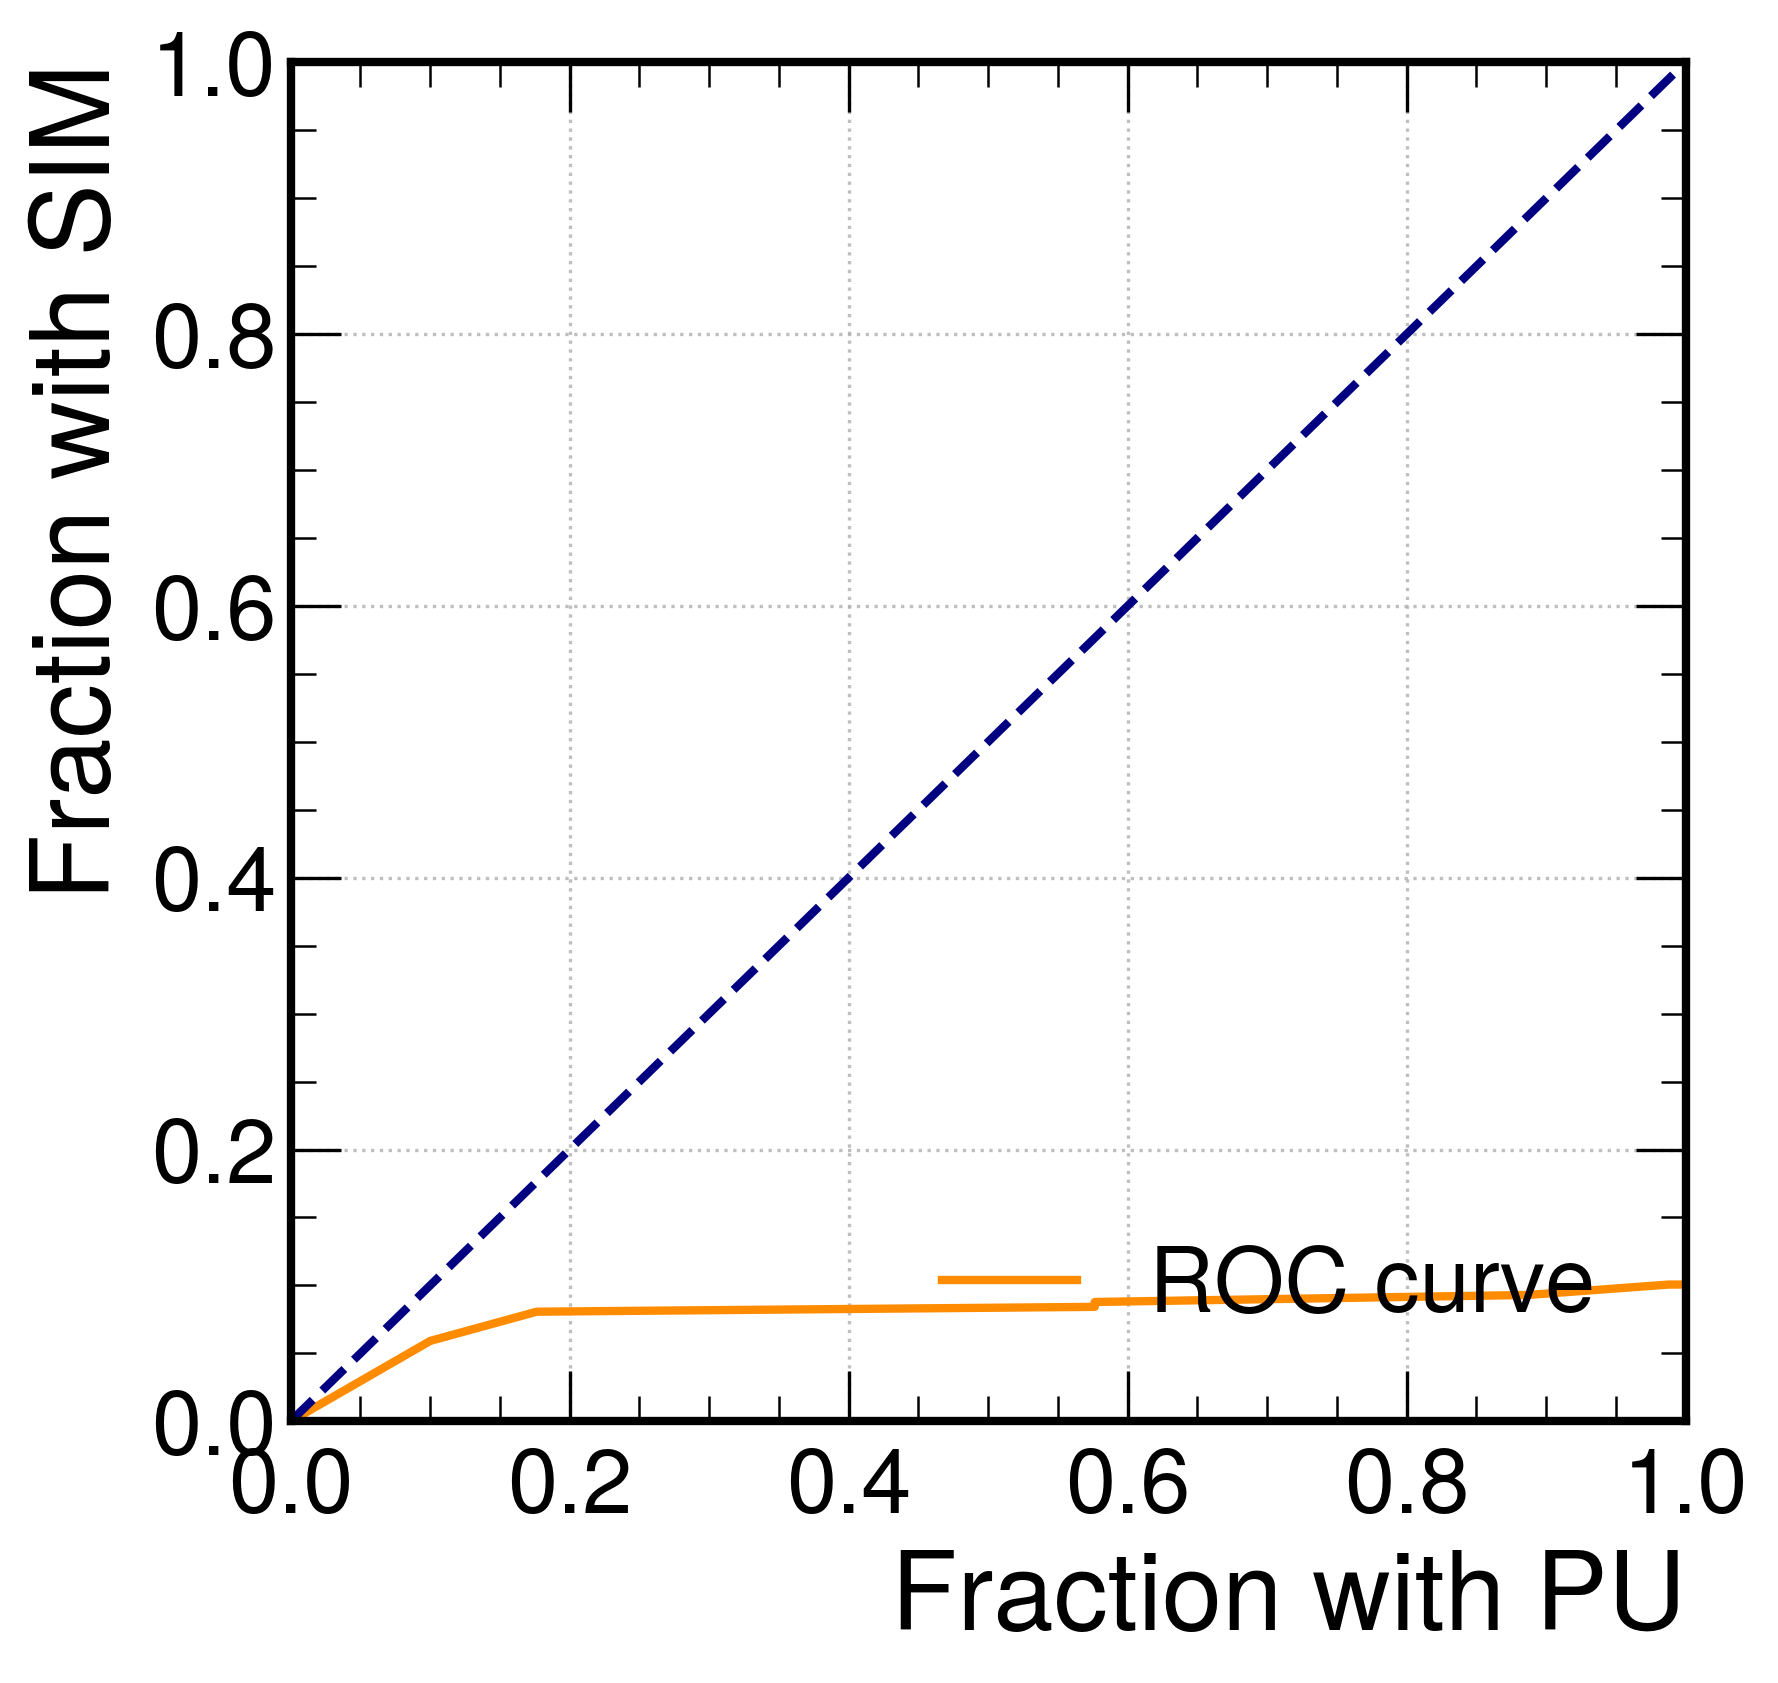

In [24]:
x, y = [], []
x.append(0)
y.append(0)
for d in dist:
    if np.max(distance) < d:
        x.append(0)
        y.append(0)
    else:
        idx = np.argmax(distance>d)
        x.append(fractionSimEnergy[idx])
        y.append(fractionRecoEnergy[idx])
        
# Plot ROC curve for validation
plt.figure(dpi=300, facecolor='white',figsize=(6,6))
# plt.axis("equal")
plt.plot(y,x, color='darkorange', lw=2, label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.ylabel('Fraction with SIM')
plt.xlabel('Fraction with PU')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## input preparation

In [25]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [26]:
array_ts_info = np.array(ts_info).T

data_dict = {
    'z': array_ts_info[1],
    'eta': array_ts_info[2],
    'phi': array_ts_info[3],
    'energy': array_ts_info[4],
    'rS' : array_ts_info[5],
    'rD' : array_ts_info[6],
    'PUc' : array_ts_info[7] / 100
}

df = pd.DataFrame(data_dict)
df_features = df[['z','eta','phi','energy']]
df_label = df[['rS', 'rD', 'PUc']]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_features, df_label, test_size=0.1, random_state=42)

# Convert to DMatrix format for XGBoost
train_dmatrix = xgb.DMatrix(X_train, label=y_train)
test_dmatrix = xgb.DMatrix(X_test, label=y_test)

# Define XGBoost parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

# Train the model
xg_reg = xgb.train(params, train_dmatrix, num_boost_round=100)

# Predict on test data
y_pred = xg_reg.predict(test_dmatrix)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.002888416077616781


In [27]:
# Assume you have a DataFrame called new_data with the same structure as your training data
new_data = pd.DataFrame({
    'z': [360,300],         # Example values for new data
    'eta': [1.7, 2.3],
    'phi': [0.3, 0.4],
    'energy': [150, 55]    # Example PU contamination values
})

# Convert to DMatrix format for XGBoost
new_dmatrix = xgb.DMatrix(new_data)

# Use the trained model to predict r values for new data
y_new_pred = xg_reg.predict(new_dmatrix)

# Display the predictions
print(f"Predicted r values for new data: {y_new_pred}")


Predicted r values for new data: [[-9.4532028e-05  1.0648661e-02 -3.7281046e-04]
 [ 7.7854246e-02  7.0323512e-02  2.1903222e-02]]


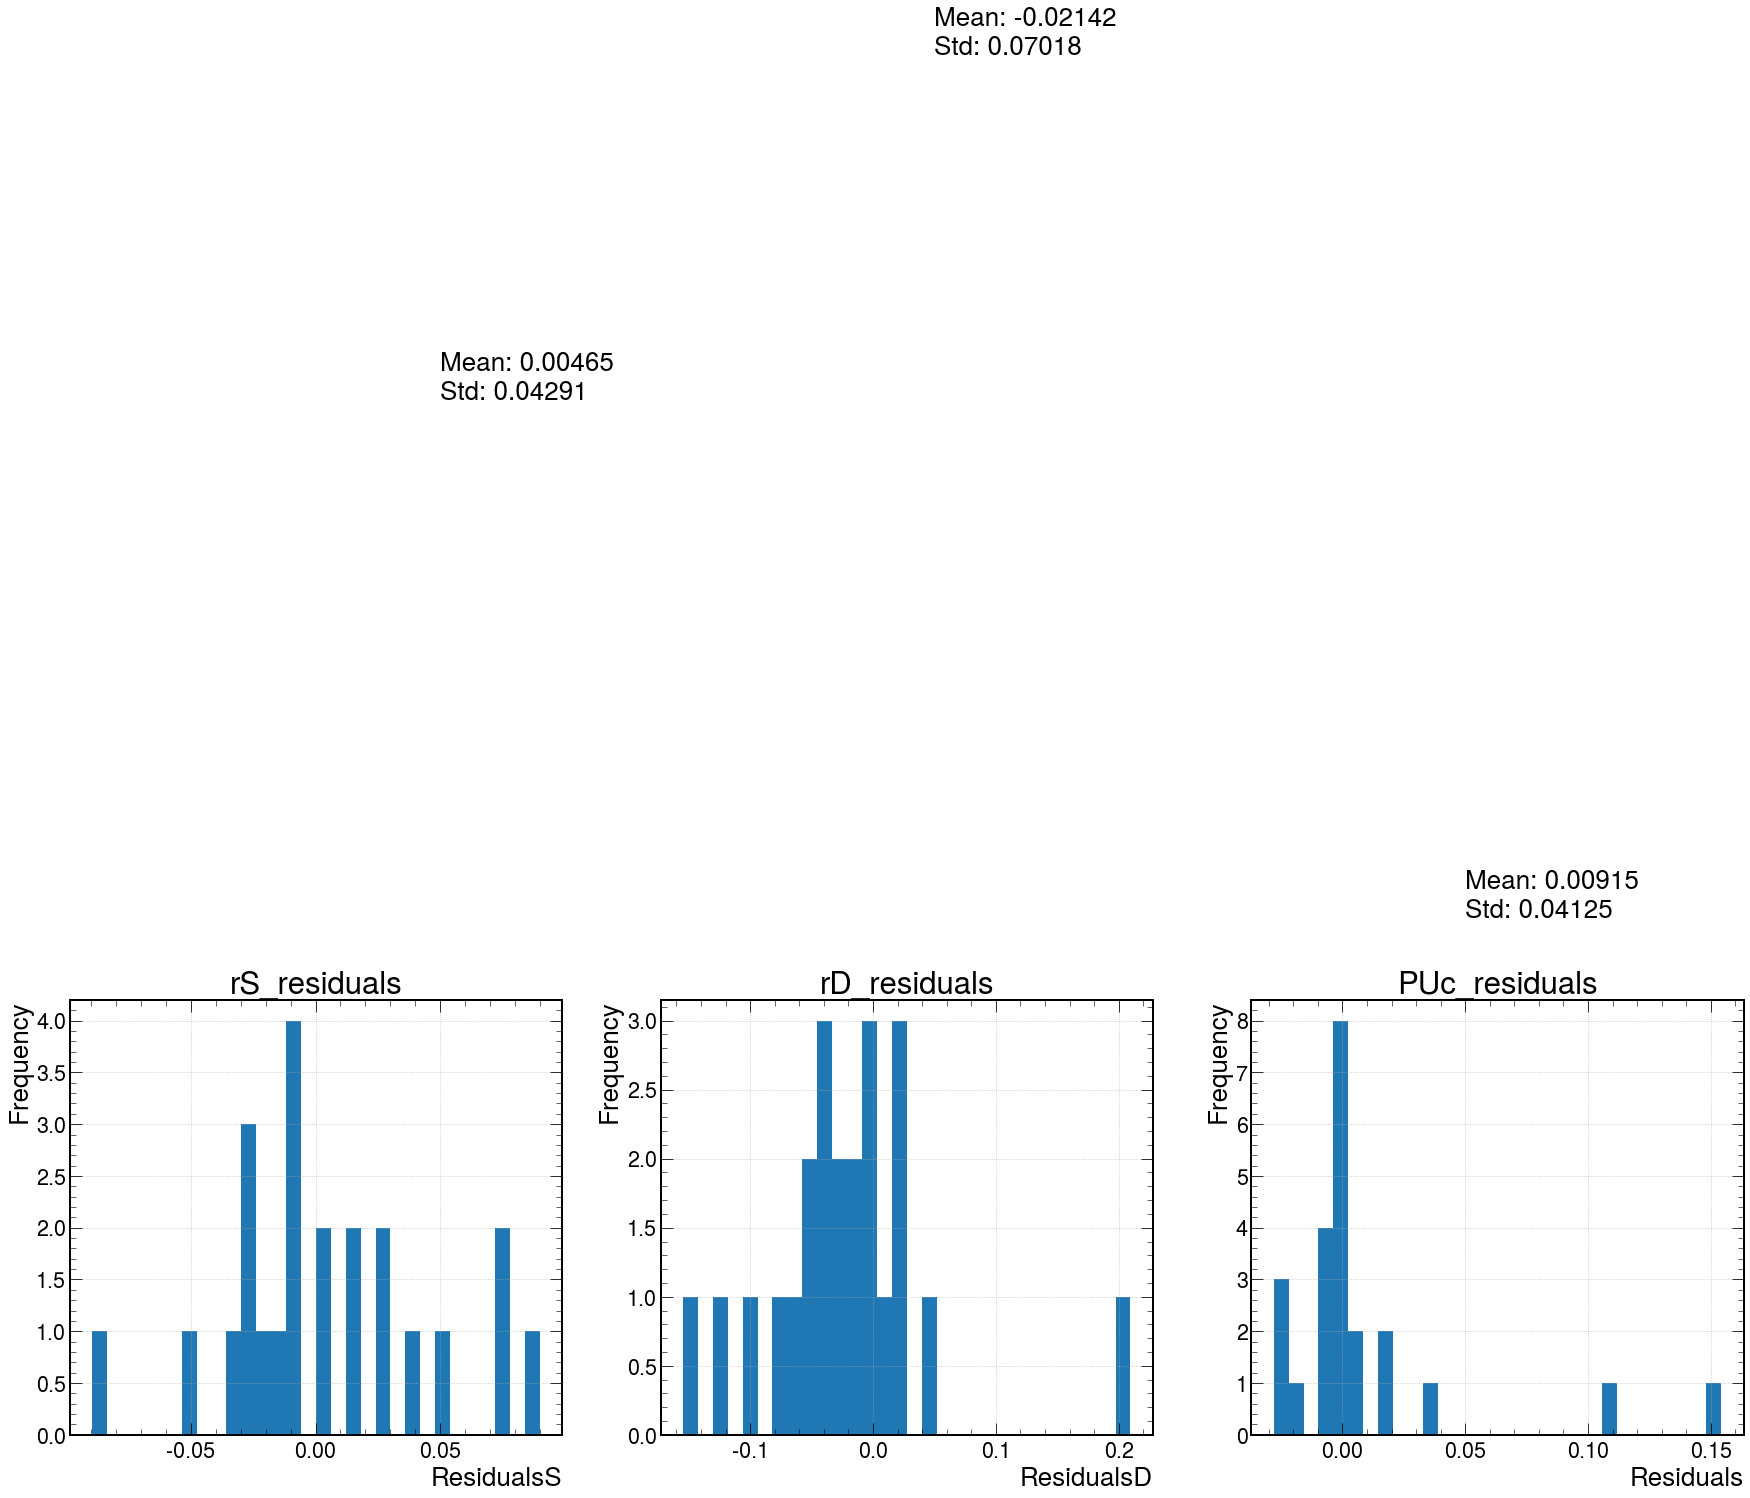

In [28]:
# Assuming y_test is a DataFrame or a numpy array with two columns (r and PUc)
# y_pred is the predicted output from the model

# Convert y_test to a numpy array (if it's a DataFrame)
y_test_array = np.array(y_test)

# Compute residuals
residuals = y_test_array - y_pred

# Convert residuals to a DataFrame for easy handling
residuals_df = pd.DataFrame(residuals, columns=['rS_residuals', 'rD_residuals', 'PUc_residuals'])

# Calculate mean and standard deviation for both r_residuals and PUc_residuals
rS_mean = residuals_df['rS_residuals'].mean()
rS_std = residuals_df['rS_residuals'].std()

rD_mean = residuals_df['rD_residuals'].mean()
rD_std = residuals_df['rD_residuals'].std()

PUc_mean = residuals_df['PUc_residuals'].mean()
PUc_std = residuals_df['PUc_residuals'].std()

# Plot the residuals
fig, axs = plt.subplots(1, 3, figsize=(30,8))
residuals_df['rS_residuals'].hist(bins=30, ax=axs[0])
axs[0].set_title(f'rS_residuals')
axs[0].text(0.05, 10, f'Mean: {rS_mean:.5f}\nStd: {rS_std:.5f}')
axs[0].set_xlabel('ResidualsS')
axs[0].set_ylabel('Frequency')

residuals_df['rD_residuals'].hist(bins=30, ax=axs[1])
axs[1].set_title(f'rD_residuals')
axs[1].text(0.05, 10, f'Mean: {rD_mean:.5f}\nStd: {rD_std:.5f}')
axs[1].set_xlabel('ResidualsD')
axs[1].set_ylabel('Frequency')

residuals_df['PUc_residuals'].hist(bins=30, ax=axs[2])
axs[2].set_title(f'PUc_residuals')
axs[2].text(0.05, 10, f'Mean: {PUc_mean:.5f}\nStd: {PUc_std:.5f}')
axs[2].set_xlabel('Residuals')
axs[2].set_ylabel('Frequency')

# plt.tight_layout()
plt.show()

## hyperparameters tuning 

In [29]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

In [30]:
xgb_reg = XGBRegressor(objective='reg:squarederror')

# Define the parameter grid to search over
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'eta': [0.02, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'lambda': [1, 1.5, 2],
    'alpha': [0, 0.1, 0.5]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Minimize MSE
    cv=3,  # 3-fold cross-validation
    verbose=1,
    n_jobs=-1  # Use all available cores
)

# Perform grid search
grid_search.fit(X_train, y_train)

# Output the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validated MSE: {-grid_search.best_score_}")

# Train the final model with the best parameters
best_xgb = grid_search.best_estimator_

# Predict on the test data
y_pred = best_xgb.predict(X_test)

# Calculate MSE on the test set
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on test data: {mse}")


Fitting 3 folds for each of 8748 candidates, totalling 26244 fits
Best parameters found: {'alpha': 0.5, 'colsample_bytree': 1.0, 'eta': 0.02, 'gamma': 0, 'lambda': 1.5, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8}
Best cross-validated MSE: 0.0011575656469002148
Mean Squared Error on test data: 0.002620750131979125


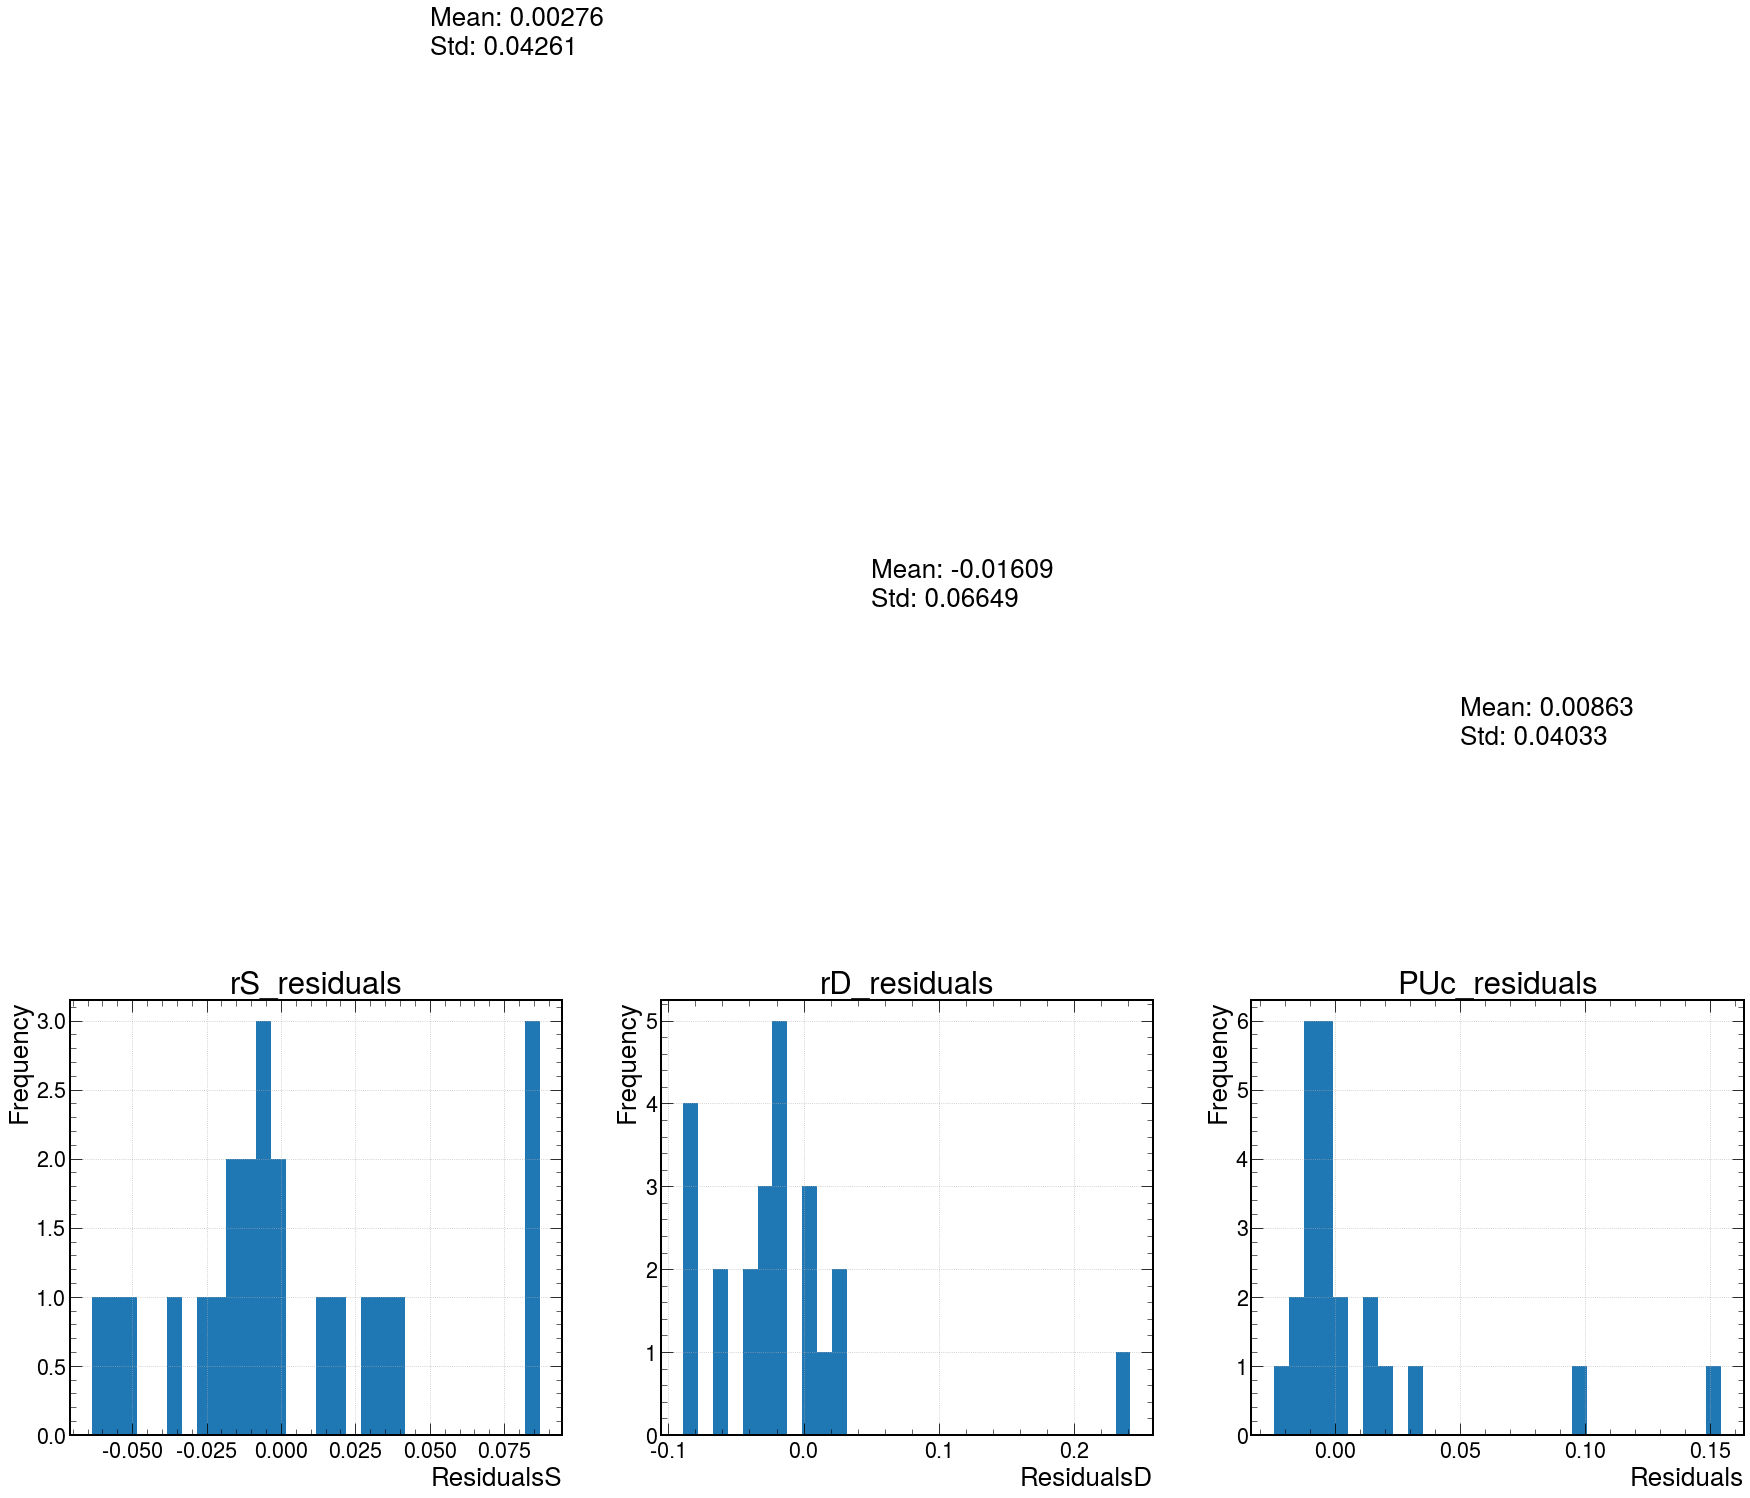

In [31]:
# Assuming y_test is a DataFrame or a numpy array with two columns (r and PUc)
# y_pred is the predicted output from the model

# Convert y_test to a numpy array (if it's a DataFrame)
y_test_array = np.array(y_test)

# Compute residuals
residuals = y_test_array - y_pred

# Convert residuals to a DataFrame for easy handling
residuals_df = pd.DataFrame(residuals, columns=['rS_residuals', 'rD_residuals', 'PUc_residuals'])

# Calculate mean and standard deviation for both r_residuals and PUc_residuals
rS_mean = residuals_df['rS_residuals'].mean()
rS_std = residuals_df['rS_residuals'].std()

rD_mean = residuals_df['rD_residuals'].mean()
rD_std = residuals_df['rD_residuals'].std()

PUc_mean = residuals_df['PUc_residuals'].mean()
PUc_std = residuals_df['PUc_residuals'].std()

# Plot the residuals
fig, axs = plt.subplots(1, 3, figsize=(30,8))
residuals_df['rS_residuals'].hist(bins=30, ax=axs[0])
axs[0].set_title(f'rS_residuals')
axs[0].text(0.05, 10, f'Mean: {rS_mean:.5f}\nStd: {rS_std:.5f}')
axs[0].set_xlabel('ResidualsS')
axs[0].set_ylabel('Frequency')

residuals_df['rD_residuals'].hist(bins=30, ax=axs[1])
axs[1].set_title(f'rD_residuals')
axs[1].text(0.05, 10, f'Mean: {rD_mean:.5f}\nStd: {rD_std:.5f}')
axs[1].set_xlabel('ResidualsD')
axs[1].set_ylabel('Frequency')

residuals_df['PUc_residuals'].hist(bins=30, ax=axs[2])
axs[2].set_title(f'PUc_residuals')
axs[2].text(0.05, 10, f'Mean: {PUc_mean:.5f}\nStd: {PUc_std:.5f}')
axs[2].set_xlabel('Residuals')
axs[2].set_ylabel('Frequency')

# plt.tight_layout()
plt.show()

## plot decision tree

In [32]:
# Get the number of trees in the model
num_trees = xg_reg.num_boosted_rounds()
print(f"Number of trees in the model: {num_trees}")


Number of trees in the model: 100


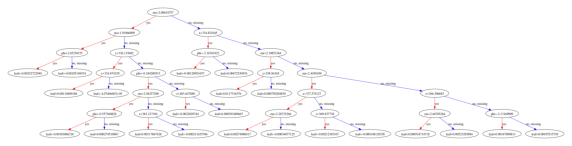

In [33]:
# Plot a specific tree (e.g., tree 0)
xgb.plot_tree(xg_reg, num_trees=0)
plt.rcParams['figure.figsize'] = [50, 10]  # Adjust the plot size to make it readable
plt.show()

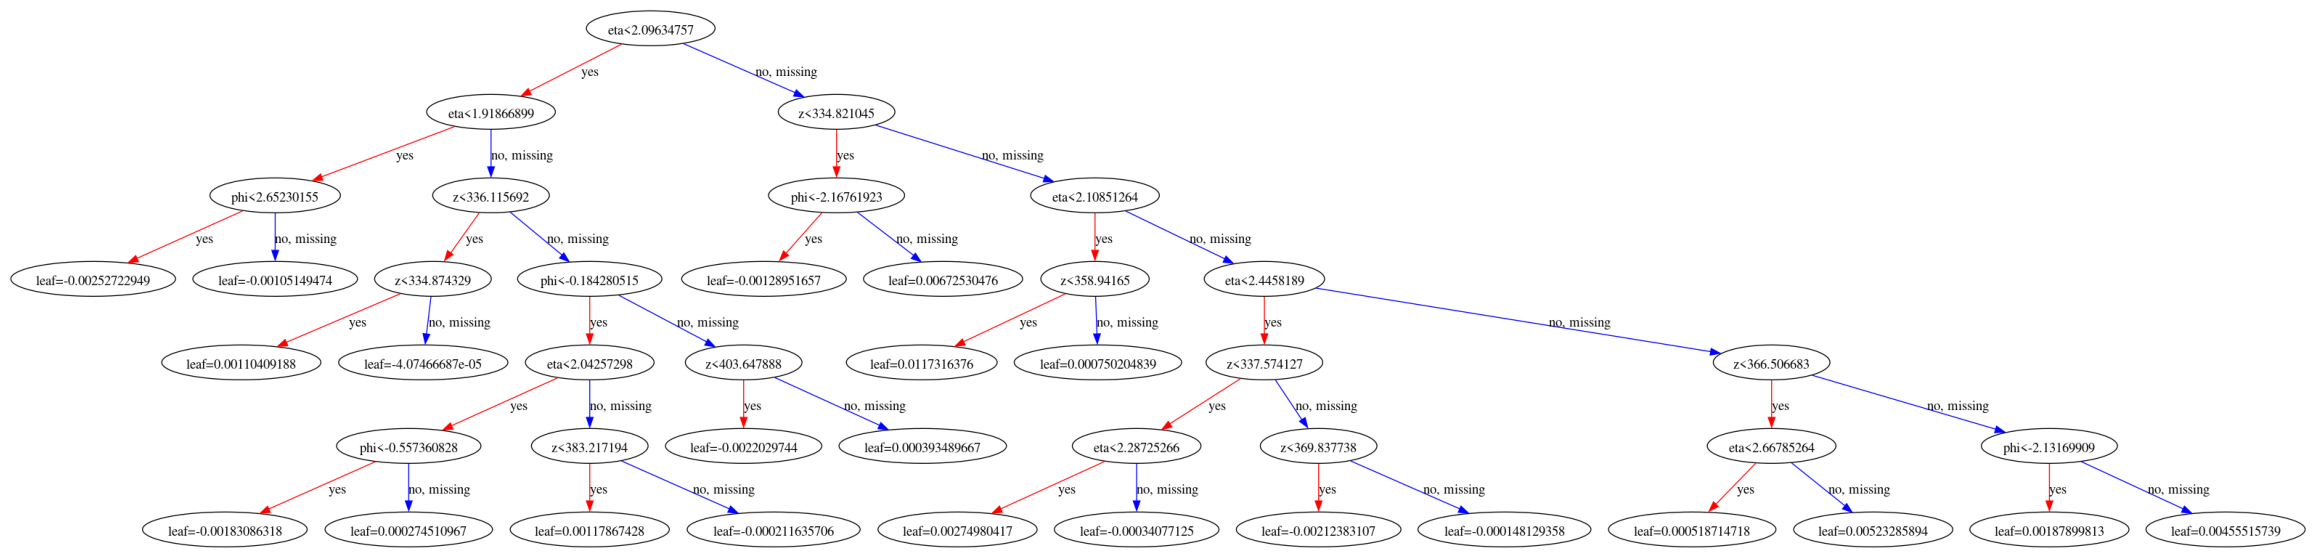

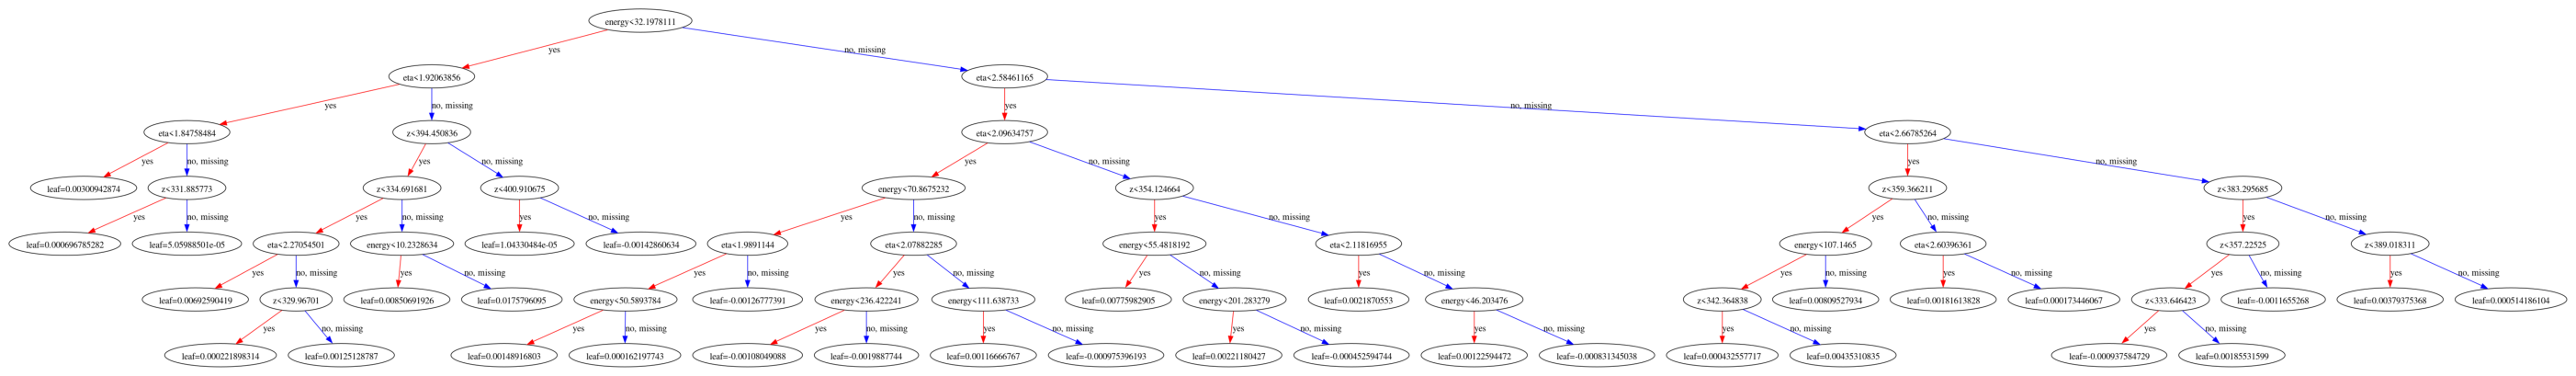

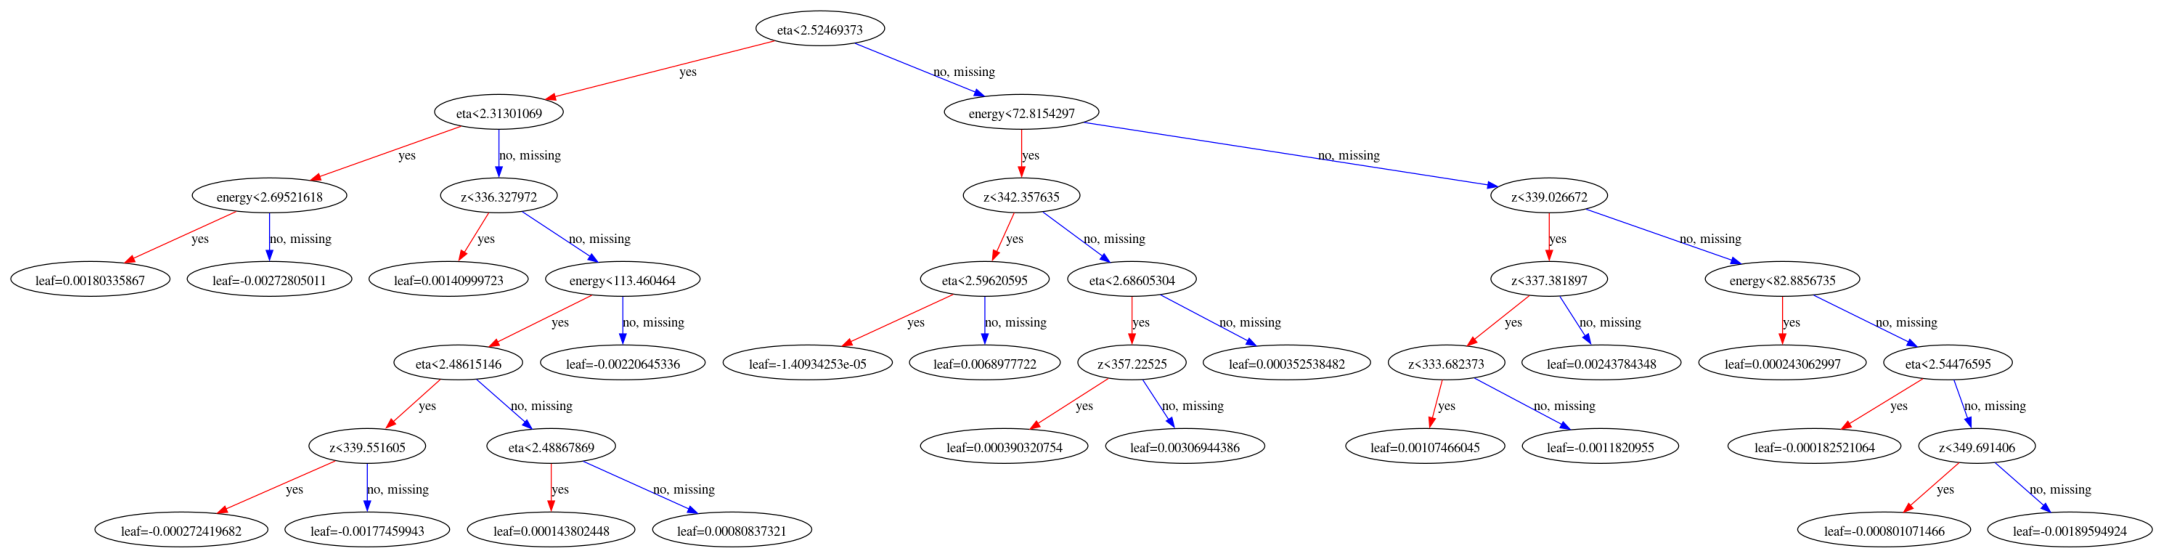

In [34]:
for i in range(3):
    xgb.plot_tree(xg_reg, num_trees=i)
    plt.show()

save and load model

In [35]:
# # save to JSON
xg_reg.save_model("model230files.json")

# model_xgb_2 = xgb.Booster()
# model_xgb_2.load_model("model.json")


## feature importance

In [36]:
# Get feature importance as a dictionary
feature_importance = xg_reg.get_score(importance_type='weight')
print("Feature Importance (by frequency):", feature_importance)

Feature Importance (by frequency): {'z': 2146.0, 'eta': 1869.0, 'phi': 1591.0, 'energy': 1633.0}


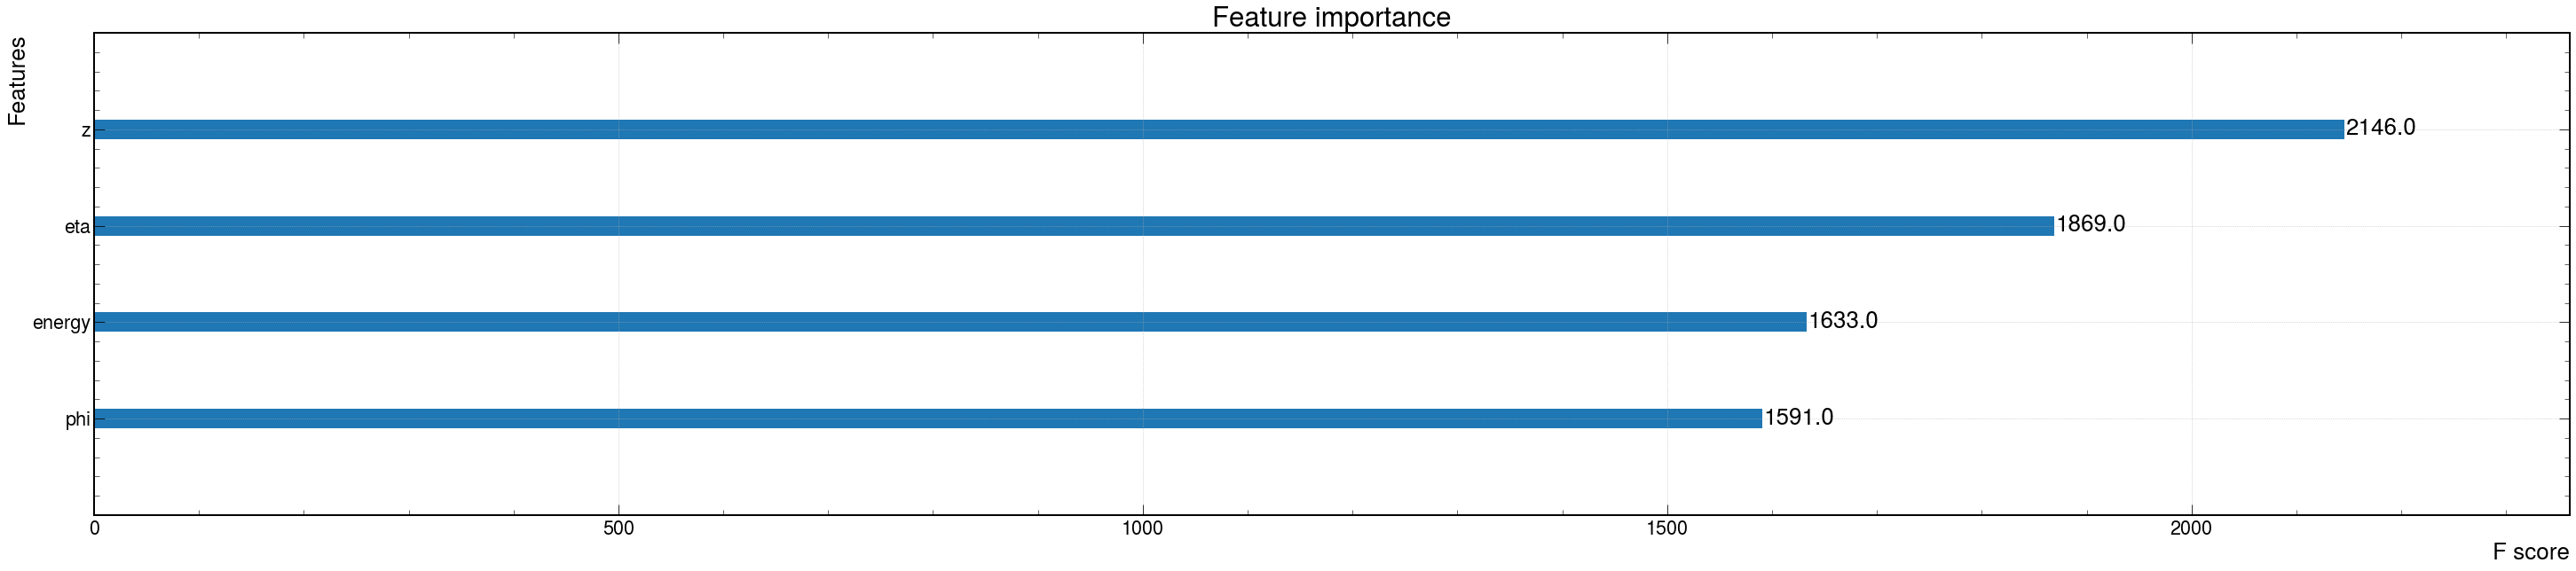

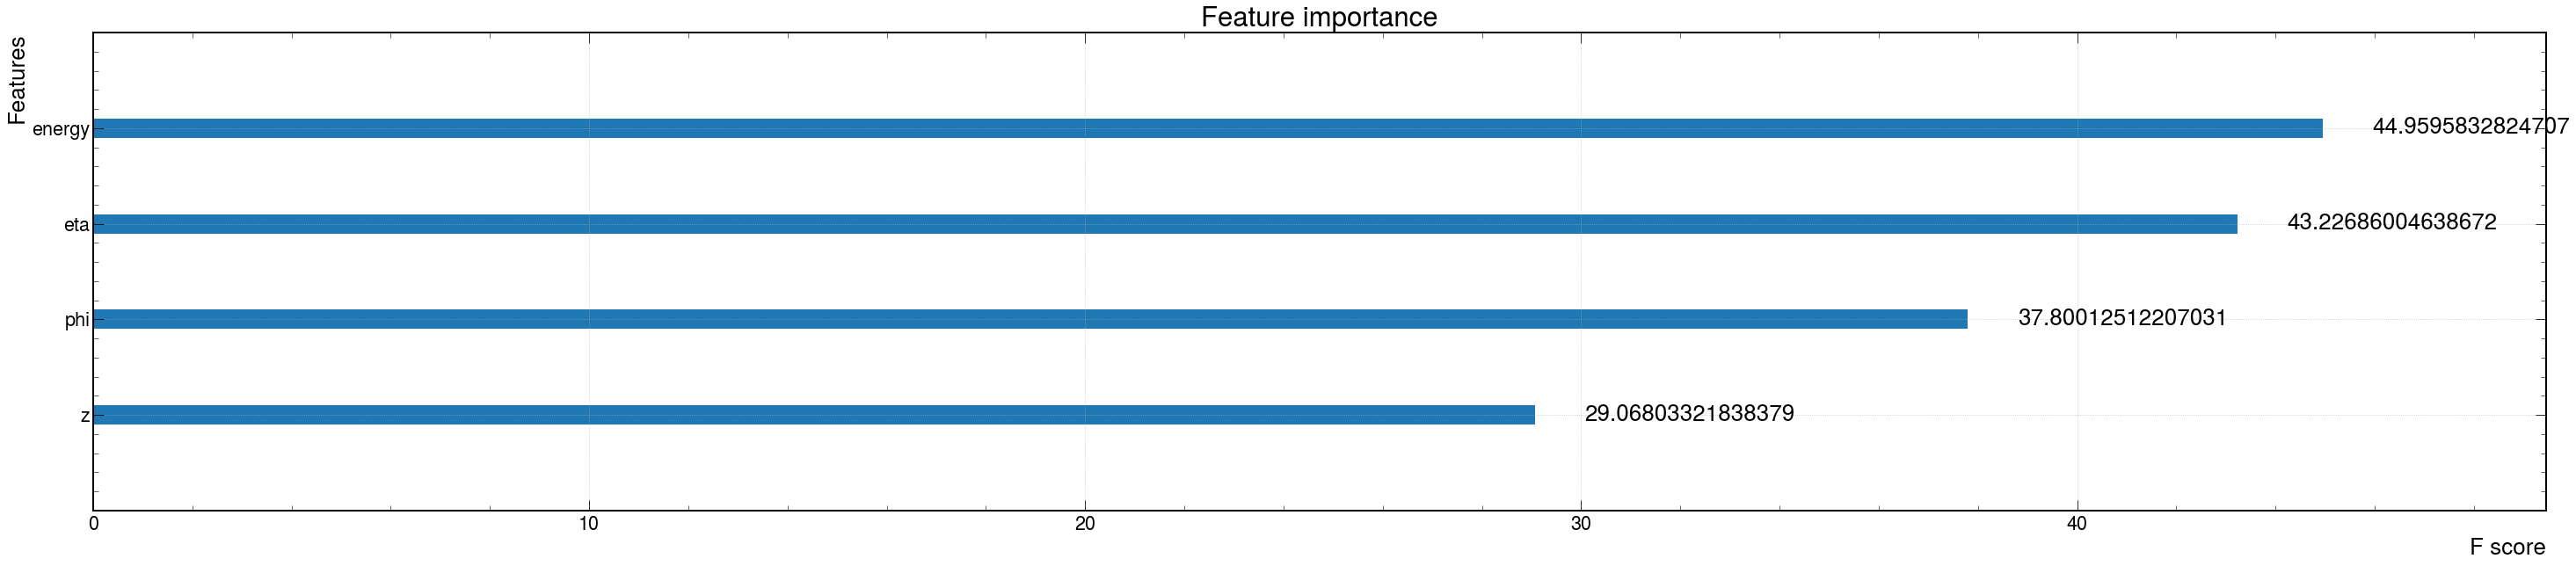

In [37]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Plot feature importance (default: based on weight, i.e., frequency)
xgb.plot_importance(xg_reg, importance_type='weight')
plt.show()

# # You can also plot feature importance based on 'gain' or 'cover':
# # Gain: the improvement in accuracy brought by a feature to the branches it is on
# ax = xgb.plot_importance(xg_reg, importance_type='gain')
# plt.show()

# Cover: the relative number of observations affected by a feature
xgb.plot_importance(xg_reg, importance_type='cover')
plt.show()


In [38]:
import pandas as pd

# Get feature importance by gain
importance_dict = xg_reg.get_score(importance_type='gain')

# Convert to a pandas DataFrame for better visualization and analysis
importance_df = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display feature importance
print(importance_df)


  Feature  Importance
3  energy    0.000984
1     eta    0.000765
2     phi    0.000489
0       z    0.000465


In [39]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: gosam 2.1.1-4b98559 has a non-standard version number. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of gosam or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: professor2 X.Y.Z has a non-standard version number. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of professor2 or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [40]:
import sys
sys.path.append('/eos/home-a/aperego/.local/lib/python3.9/site-packages')
import shap

In [41]:
print(X_test.corr())

               z       eta       phi    energy
z       1.000000  0.256323 -0.153659 -0.350303
eta     0.256323  1.000000 -0.266614 -0.455132
phi    -0.153659 -0.266614  1.000000  0.374584
energy -0.350303 -0.455132  0.374584  1.000000


In [42]:
# Create an explainer using your trained model
explainer = shap.TreeExplainer(xg_reg)

# Compute SHAP values for your test data
shap_values = explainer.shap_values(X_test)

In [43]:
# Assuming two outputs, you can extract SHAP values for each
shap_values_r = shap_values[:, :, 0]  # SHAP values for the first output 'r'
shap_values_puc = shap_values[:, :, 1]  # SHAP values for the second output 'PUc'

# Convert SHAP values for 'r' to a DataFrame
shap_values_r_df = pd.DataFrame(shap_values_r, columns=X_test.columns)
print(shap_values_r_df.describe())

# Convert SHAP values for 'PUc' to a DataFrame (optional, if you want to analyze PUc separately)
shap_values_puc_df = pd.DataFrame(shap_values_puc, columns=X_test.columns)
print(shap_values_puc_df.describe())

               z        eta        phi     energy
count  23.000000  23.000000  23.000000  23.000000
mean    0.001584   0.008162  -0.002832   0.005856
std     0.009279   0.018101   0.006071   0.012262
min    -0.013072  -0.031498  -0.016062  -0.016698
25%    -0.006232  -0.004935  -0.005822  -0.006604
50%     0.002473   0.012215  -0.000931   0.008608
75%     0.005328   0.022444   0.000780   0.016370
max     0.026121   0.045012   0.006502   0.022307
               z        eta        phi     energy
count  23.000000  23.000000  23.000000  23.000000
mean   -0.001258   0.008030   0.003215   0.018842
std     0.015665   0.019275   0.008485   0.038360
min    -0.024520  -0.034085  -0.004999  -0.023896
25%    -0.015047   0.000672  -0.001962  -0.010058
50%     0.004350   0.007163   0.001252  -0.003521
75%     0.011911   0.018028   0.002604   0.057973
max     0.031156   0.040966   0.025686   0.089362


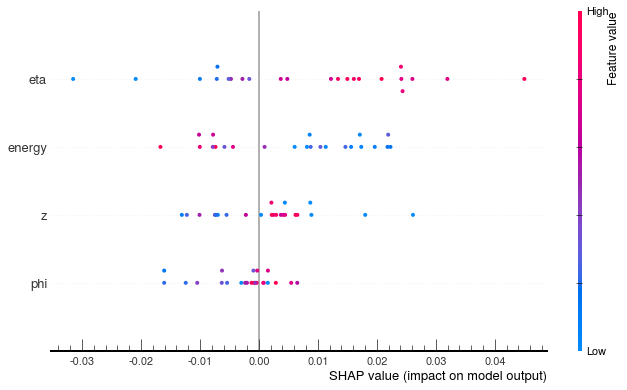

In [44]:
# Plot SHAP summary for 'r'
shap.summary_plot(shap_values_r, X_test, plot_size=(10,6)) # , max_display=X_test.shape[1] is for the max number of variables to be displayed (default is 20)

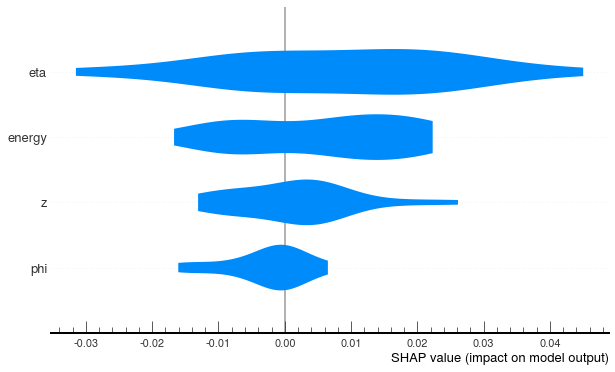

In [45]:
shap.plots.violin(shap_values_r, plot_size=(10,6), feature_names=shap_values_r_df.columns)

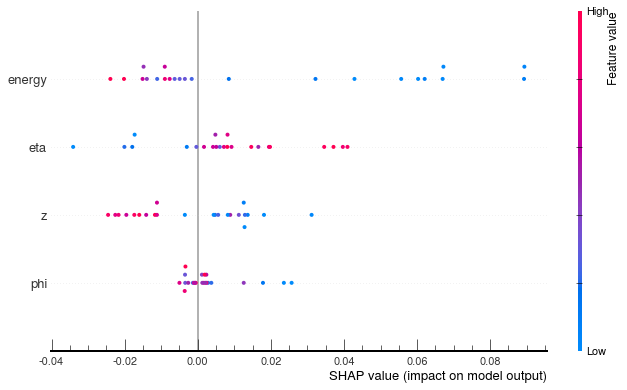

In [46]:
# Plot SHAP summary for 'PUc'
shap.summary_plot(shap_values_puc, X_test, plot_size=(10,6))

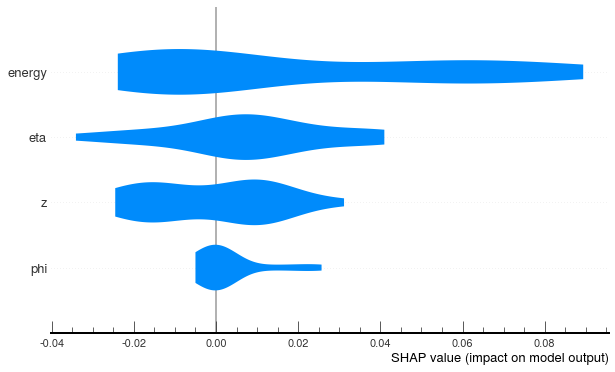

In [47]:
shap.plots.violin(shap_values_puc, plot_size=(10,6), feature_names=shap_values_r_df.columns)